### Synthetic data generation

In [ ]:
# ── 0. Imports ────────────────────────────────────────────────────────────────
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

from itertools import product

In [ ]:
# ── 1. Configuration ──────────────────────────────────────────────────────────
SEED = 42

VALUE_COL   = "p99_latency_seconds"
DATE_COL    = "date"
UNIT_COL    = "unit_id"
ENV_COL     = "env_type"
SEGMENT_COL = "segment_id"
MACRO_COL   = "macro_id"
TRUTH_COL   = "is_injected_anomaly"

BASELINES = {
    "X": 40.0,
    "Y": 80.0,
    "Z": 120.0,
}

INVOCATIONS = {
    "X": 5000,
    "Y": 1000,
    "Z": 100,
}

ENV_COLOR = {
    "X": "#1f77b4",
    "Y": "#ff7f0e",
    "Z": "#2ca02c",
}

SCENARIO_NAMES = {
    "A": "easy_short_regression",
    "B": "multi_env_short_anomalies",
    "C": "hidden_local_regression",
    "D": "long_term_trend",
    "E": "mixed_realistic_system",
}


# ── 2. Base hierarchy ─────────────────────────────────────────────────────────
def build_hierarchy():
    """
    Creates:
    2 macro nodes
    2 segments per macro
    3 units per segment

    Total: 12 units.
    Env assignment: 4 units X, 4 units Y, 4 units Z.
    """
    rows = []
    unit_num = 1

    env_sequence = ["X"] * 4 + ["Y"] * 4 + ["Z"] * 4

    for macro_idx in range(1, 3):
        macro_id = f"macro_{macro_idx}"

        for segment_idx in range(1, 3):
            segment_id = f"{macro_id}_segment_{segment_idx}"

            for local_unit_idx in range(1, 4):
                unit_id = f"u{unit_num:02d}"
                env_type = env_sequence[unit_num - 1]

                rows.append({
                    MACRO_COL: macro_id,
                    SEGMENT_COL: segment_id,
                    UNIT_COL: unit_id,
                    ENV_COL: env_type,
                })

                unit_num += 1

    return pd.DataFrame(rows)


# ── 3. Base synthetic latency generator ───────────────────────────────────────
def generate_base_latency_data(
    days=90,
    start_date="2024-01-01",
    seed=42,
    noise_factor=0.20,
    invocation_jitter=0.10,
    unit_effect_std=0.03,
    global_day_effect_std=0.015,
):
    """
    Generates clean synthetic p99 latency data without injected anomalies.

    Important:
    - X has high volume and low variance.
    - Y has medium volume and medium variance.
    - Z has low volume and high variance.
    """
    rng = np.random.default_rng(seed)

    hierarchy = build_hierarchy()
    dates = pd.date_range(start=start_date, periods=days, freq="D")

    # Unit-specific multiplier, so units from the same env are not identical.
    unit_effects = {
        unit: rng.normal(loc=1.0, scale=unit_effect_std)
        for unit in hierarchy[UNIT_COL].unique()
    }

    # Global day effect, simulating days when the whole system is slightly faster/slower.
    day_effects = {
        date: rng.normal(loc=1.0, scale=global_day_effect_std)
        for date in dates
    }

    rows = []

    for _, unit_row in hierarchy.iterrows():
        env = unit_row[ENV_COL]
        baseline = BASELINES[env]
        base_invocations = INVOCATIONS[env]

        for date in dates:
            daily_invocations = int(
                max(
                    1,
                    rng.normal(
                        loc=base_invocations,
                        scale=base_invocations * invocation_jitter,
                    )
                )
            )

            # Noise inversely proportional to sqrt(invocations).
            noise_std = baseline * noise_factor / np.sqrt(daily_invocations / 100)

            latency = (
                baseline
                * unit_effects[unit_row[UNIT_COL]]
                * day_effects[date]
                + rng.normal(loc=0.0, scale=noise_std)
            )

            # Latency cannot be negative.
            latency = max(latency, baseline * 0.20)

            rows.append({
                DATE_COL: date,
                MACRO_COL: unit_row[MACRO_COL],
                SEGMENT_COL: unit_row[SEGMENT_COL],
                UNIT_COL: unit_row[UNIT_COL],
                ENV_COL: env,
                "daily_invocations": daily_invocations,
                VALUE_COL: latency,
                TRUTH_COL: False,
                "anomaly_event_id": "none",
                "anomaly_type": "none",
                "anomaly_scope": "none",
                "anomaly_increase_pct": 0.0,
                "has_injected_trend": False,
                "trend_strength": 0.0,
                "expected_detection_type": "none",
            })

    df = pd.DataFrame(rows)
    return df.sort_values([UNIT_COL, DATE_COL]).reset_index(drop=True)


# ── 4. Injection helpers ──────────────────────────────────────────────────────
def inject_window_anomaly(
    df,
    unit_ids=None,
    segment_ids=None,
    macro_ids=None,
    start_day=15,
    end_day=22,
    increase_pct=0.50,
    event_id="A001",
    anomaly_type="short_regression",
    anomaly_scope="unit",
    expected_detection_type="window",
):
    """
    Injects anomaly between start_day and end_day inclusive.
    Days are 1-indexed: day 1 means first date in the dataset.
    """
    out = df.copy()

    unique_dates = sorted(out[DATE_COL].unique())
    start_date = unique_dates[start_day - 1]
    end_date = unique_dates[end_day - 1]

    mask = (out[DATE_COL] >= start_date) & (out[DATE_COL] <= end_date)

    if unit_ids is not None:
        mask &= out[UNIT_COL].isin(unit_ids)

    if segment_ids is not None:
        mask &= out[SEGMENT_COL].isin(segment_ids)

    if macro_ids is not None:
        mask &= out[MACRO_COL].isin(macro_ids)

    out.loc[mask, VALUE_COL] *= (1.0 + increase_pct)
    out.loc[mask, TRUTH_COL] = True
    out.loc[mask, "anomaly_event_id"] = event_id
    out.loc[mask, "anomaly_type"] = anomaly_type
    out.loc[mask, "anomaly_scope"] = anomaly_scope
    out.loc[mask, "anomaly_increase_pct"] = increase_pct
    out.loc[mask, "expected_detection_type"] = expected_detection_type

    return out


def inject_long_trend(
    df,
    unit_ids=None,
    segment_ids=None,
    macro_ids=None,
    start_day=30,
    end_day=90,
    daily_increase_pct=0.004,
    event_id="D001",
    anomaly_scope="unit",
):
    """
    Injects gradual long-term degradation.
    Example:
    daily_increase_pct = 0.004 means +0.4% per day after start_day.
    """
    out = df.copy()

    unique_dates = sorted(out[DATE_COL].unique())
    start_date = unique_dates[start_day - 1]
    end_date = unique_dates[end_day - 1]

    mask = (out[DATE_COL] >= start_date) & (out[DATE_COL] <= end_date)

    if unit_ids is not None:
        mask &= out[UNIT_COL].isin(unit_ids)

    if segment_ids is not None:
        mask &= out[SEGMENT_COL].isin(segment_ids)

    if macro_ids is not None:
        mask &= out[MACRO_COL].isin(macro_ids)

    days_since_start = (
        out.loc[mask, DATE_COL] - pd.Timestamp(start_date)
    ).dt.days

    trend_multiplier = 1.0 + daily_increase_pct * days_since_start

    out.loc[mask, VALUE_COL] *= trend_multiplier.values
    out.loc[mask, TRUTH_COL] = True
    out.loc[mask, "anomaly_event_id"] = event_id
    out.loc[mask, "anomaly_type"] = "long_trend"
    out.loc[mask, "anomaly_scope"] = anomaly_scope
    out.loc[mask, "anomaly_increase_pct"] = trend_multiplier.values - 1.0
    out.loc[mask, "has_injected_trend"] = True
    out.loc[mask, "trend_strength"] = daily_increase_pct
    out.loc[mask, "expected_detection_type"] = "trend"

    return out


def inject_non_anomalous_jitter(
    df,
    env_type="Z",
    n_points=8,
    increase_pct_range=(0.20, 0.45),
    seed=42,
):
    """
    Adds natural-looking high jitter points that are NOT marked as anomalies.
    This is useful for testing false positives.
    """
    rng = np.random.default_rng(seed)
    out = df.copy()

    candidates = out[
        (out[ENV_COL] == env_type) &
        (~out[TRUTH_COL])
    ].index.to_numpy()

    selected_idx = rng.choice(
        candidates,
        size=min(n_points, len(candidates)),
        replace=False,
    )

    multipliers = 1.0 + rng.uniform(
        increase_pct_range[0],
        increase_pct_range[1],
        size=len(selected_idx),
    )

    out.loc[selected_idx, VALUE_COL] *= multipliers

    # Important: we do NOT set is_injected_anomaly = True here.
    out.loc[selected_idx, "anomaly_type"] = out.loc[selected_idx, "anomaly_type"].where(
        out.loc[selected_idx, TRUTH_COL],
        "natural_jitter_not_anomaly"
    )

    return out


# ── 5. Scenario generator A-E ─────────────────────────────────────────────────
def generate_latency_dataset(
    scenario="A",
    days=90,
    start_date="2024-01-01",
    seed=42,
    save_csv=False,
):
    """
    Scenarios:
    A - easy short regression
    B - short anomalies in X, Y, Z
    C - subtle local anomaly hidden in aggregation
    D - long-term trend
    E - mixed realistic system
    """
    scenario = scenario.upper()

    if scenario not in SCENARIO_NAMES:
        raise ValueError(f"Unknown scenario: {scenario}. Use one of: A, B, C, D, E")

    df = generate_base_latency_data(
        days=days,
        start_date=start_date,
        seed=seed,
    )

    # Convenient unit groups.
    units_by_env = {
        env: df[df[ENV_COL] == env][UNIT_COL].drop_duplicates().tolist()
        for env in ["X", "Y", "Z"]
    }

    # Scenario A: one obvious X regression.
    if scenario == "A":
        df = inject_window_anomaly(
            df,
            unit_ids=[units_by_env["X"][0]],
            start_day=15,
            end_day=22,
            increase_pct=0.50,
            event_id="A001",
            anomaly_type="short_regression",
            anomaly_scope="unit",
            expected_detection_type="window",
        )

    # Scenario B: several short anomalies across environments.
    elif scenario == "B":
        df = inject_window_anomaly(
            df,
            unit_ids=[units_by_env["X"][0]],
            start_day=12,
            end_day=16,
            increase_pct=0.50,
            event_id="B001",
            anomaly_type="short_regression",
            anomaly_scope="unit",
        )

        df = inject_window_anomaly(
            df,
            unit_ids=[units_by_env["Y"][1]],
            start_day=30,
            end_day=33,
            increase_pct=0.35,
            event_id="B002",
            anomaly_type="short_regression",
            anomaly_scope="unit",
        )

        df = inject_window_anomaly(
            df,
            unit_ids=[units_by_env["Z"][2]],
            start_day=55,
            end_day=57,
            increase_pct=0.40,
            event_id="B003",
            anomaly_type="short_regression",
            anomaly_scope="unit",
        )

    # Scenario C: subtle local anomaly, likely hidden after aggregation.
    elif scenario == "C":
        df = inject_window_anomaly(
            df,
            unit_ids=[units_by_env["X"][2]],
            start_day=35,
            end_day=44,
            increase_pct=0.25,
            event_id="C001",
            anomaly_type="subtle_local_regression",
            anomaly_scope="unit",
            expected_detection_type="window",
        )

    # Scenario D: long-term trend.
    elif scenario == "D":
        df = inject_long_trend(
            df,
            unit_ids=[units_by_env["Y"][0]],
            start_day=30,
            end_day=90,
            daily_increase_pct=0.004,
            event_id="D001",
            anomaly_scope="unit",
        )

    # Scenario E: mixed realistic system.
    elif scenario == "E":
        # Short X spike/regression.
        df = inject_window_anomaly(
            df,
            unit_ids=[units_by_env["X"][0]],
            start_day=12,
            end_day=14,
            increase_pct=0.60,
            event_id="E001",
            anomaly_type="short_spike",
            anomaly_scope="unit",
            expected_detection_type="point_or_window",
        )

        # Medium Y regression.
        df = inject_window_anomaly(
            df,
            unit_ids=[units_by_env["Y"][1]],
            start_day=25,
            end_day=31,
            increase_pct=0.30,
            event_id="E002",
            anomaly_type="short_regression",
            anomaly_scope="unit",
            expected_detection_type="window",
        )

        # Difficult Z anomaly.
        df = inject_window_anomaly(
            df,
            unit_ids=[units_by_env["Z"][2]],
            start_day=40,
            end_day=42,
            increase_pct=0.45,
            event_id="E003",
            anomaly_type="short_regression_noisy_env",
            anomaly_scope="unit",
            expected_detection_type="window",
        )

        # Segment-level subtle regression.
        target_segment = df[df[UNIT_COL] == units_by_env["X"][1]][SEGMENT_COL].iloc[0]

        df = inject_window_anomaly(
            df,
            segment_ids=[target_segment],
            start_day=50,
            end_day=58,
            increase_pct=0.15,
            event_id="E004",
            anomaly_type="subtle_segment_regression",
            anomaly_scope="segment",
            expected_detection_type="contextual_or_window",
        )

        # Macro-level long trend.
        df = inject_long_trend(
            df,
            macro_ids=["macro_2"],
            start_day=65,
            end_day=90,
            daily_increase_pct=0.004,
            event_id="E005",
            anomaly_scope="macro",
        )

        # Non-anomalous natural jitter in Z to test false positives.
        df = inject_non_anomalous_jitter(
            df,
            env_type="Z",
            n_points=10,
            increase_pct_range=(0.20, 0.45),
            seed=seed + 100,
        )

    df["scenario"] = scenario
    df["scenario_name"] = SCENARIO_NAMES[scenario]

    df = df.sort_values([UNIT_COL, DATE_COL]).reset_index(drop=True)

    if save_csv:
        filename = f"latency_dataset_{scenario}_{SCENARIO_NAMES[scenario]}_seed_{seed}.csv"
        df.to_csv(filename, index=False)
        print(f"Saved: {filename}")

    return df


# ── 6. Generate all scenarios ─────────────────────────────────────────────────
def generate_all_latency_datasets(
    seed=42,
    save_csv=True,
):
    scenario_frames = []

    for scenario in ["A", "B", "C", "D", "E"]:
        df_scenario = generate_latency_dataset(
            scenario=scenario,
            seed=seed,
            save_csv=save_csv,
        )
        scenario_frames.append(df_scenario)

    all_df = pd.concat(scenario_frames, ignore_index=True)

    if save_csv:
        all_df.to_csv(f"latency_all_scenarios_seed_{seed}.csv", index=False)
        print(f"Saved: latency_all_scenarios_seed_{seed}.csv")

    return all_df

In [ ]:
all_df = generate_all_latency_datasets(
    seed=42,
    save_csv=True,
)

all_df.head()

Saved: latency_dataset_A_easy_short_regression_seed_42.csv
Saved: latency_dataset_B_multi_env_short_anomalies_seed_42.csv
Saved: latency_dataset_C_hidden_local_regression_seed_42.csv
Saved: latency_dataset_D_long_term_trend_seed_42.csv
Saved: latency_dataset_E_mixed_realistic_system_seed_42.csv
Saved: latency_all_scenarios_seed_42.csv


,date,macro_id,segment_id,unit_id,env_type,daily_invocations,p99_latency_seconds,is_injected_anomaly,anomaly_event_id,anomaly_type,anomaly_scope,anomaly_increase_pct,has_injected_trend,trend_strength,expected_detection_type,scenario,scenario_name
0,2024-01-01,macro_1,macro_1_segment_1,u01,X,4821,41.255394,False,none,none,none,0.0,False,0.0,none,A,easy_short_regression
1,2024-01-02,macro_1,macro_1_segment_1,u01,X,4533,40.804083,False,none,none,none,0.0,False,0.0,none,A,easy_short_regression
2,2024-01-03,macro_1,macro_1_segment_1,u01,X,4524,40.245484,False,none,none,none,0.0,False,0.0,none,A,easy_short_regression
3,2024-01-04,macro_1,macro_1_segment_1,u01,X,5420,37.968376,False,none,none,none,0.0,False,0.0,none,A,easy_short_regression
4,2024-01-05,macro_1,macro_1_segment_1,u01,X,5217,40.852247,False,none,none,none,0.0,False,0.0,none,A,easy_short_regression


### Dataset visualization

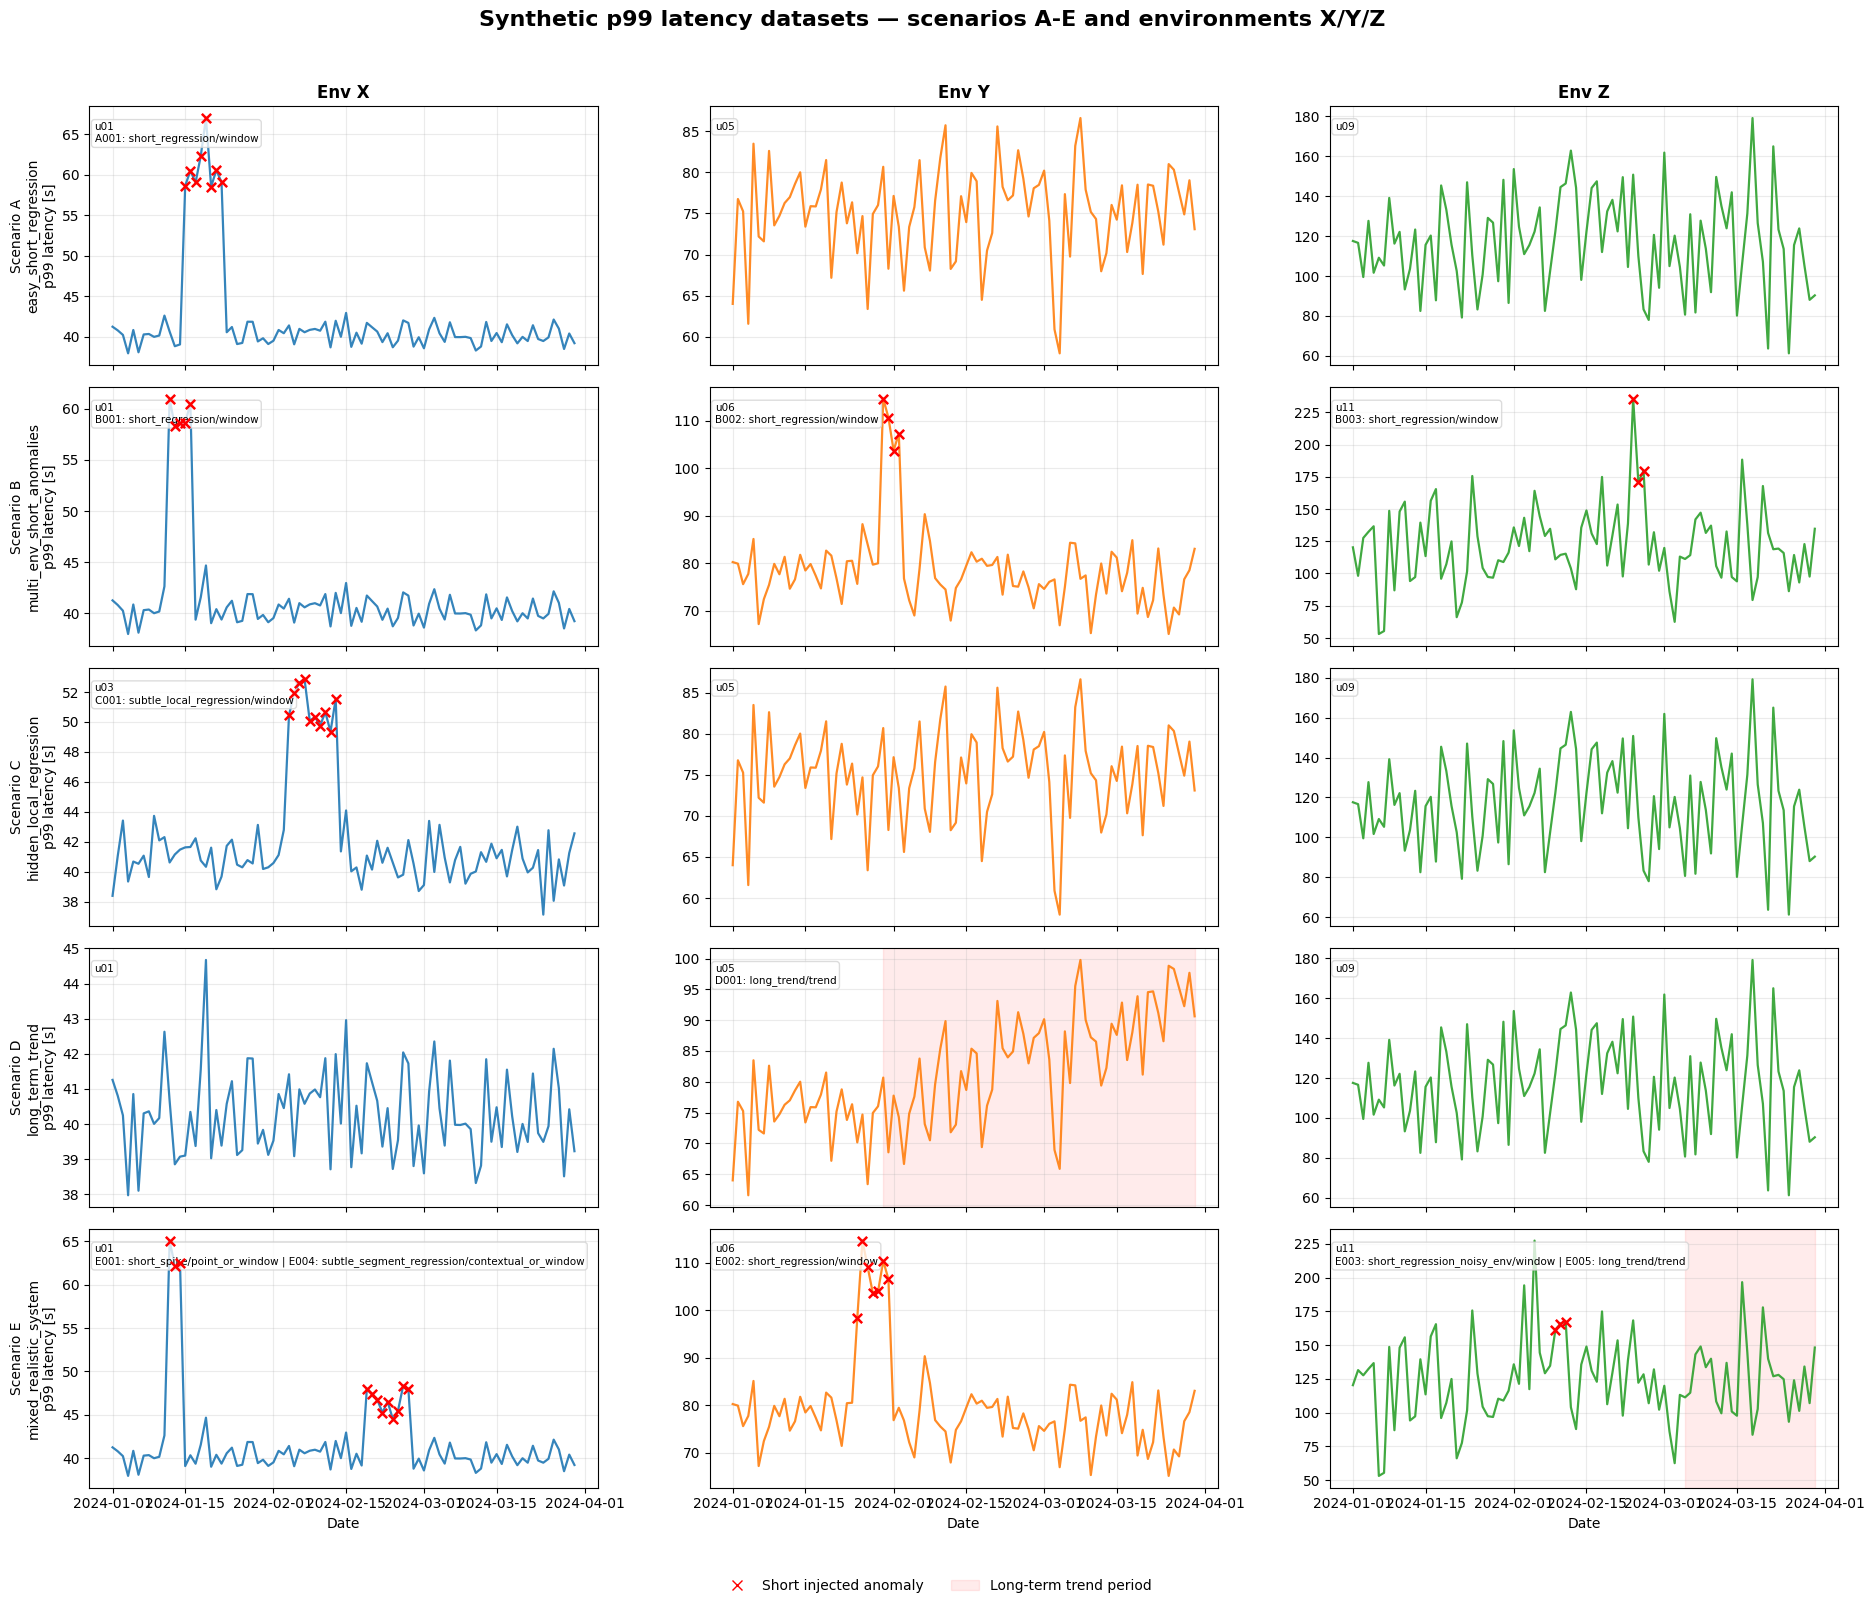

In [ ]:
# ── Visualization helpers for scenarios A-E ──────────────────────────────────

import matplotlib.lines as mlines
import matplotlib.patches as mpatches


def get_event_summary(unit_data):
    """
    Creates a short readable event summary for a single plotted unit.
    """
    anomaly_data = unit_data[unit_data[TRUTH_COL]].copy()

    if anomaly_data.empty:
        return ""

    event_summary = (
        anomaly_data[
            ["anomaly_event_id", "anomaly_type", "expected_detection_type"]
        ]
        .drop_duplicates()
        .sort_values("anomaly_event_id")
    )

    labels = []

    for _, row in event_summary.iterrows():
        event_id = row["anomaly_event_id"]
        anomaly_type = row["anomaly_type"]
        detection_type = row["expected_detection_type"]

        labels.append(f"{event_id}: {anomaly_type}/{detection_type}")

    return " | ".join(labels)


def choose_representative_unit(data, env):
    """
    Chooses one representative unit for a given environment.

    Priority:
    1. Unit with non-trend injected anomaly.
    2. Unit with trend anomaly.
    3. First available unit.
    """
    env_data = data[data[ENV_COL] == env].copy()

    non_trend_units = (
        env_data[
            (env_data[TRUTH_COL]) &
            (env_data["expected_detection_type"] != "trend")
        ][UNIT_COL]
        .drop_duplicates()
        .tolist()
    )

    if len(non_trend_units) > 0:
        return non_trend_units[0]

    trend_units = (
        env_data[
            (env_data[TRUTH_COL]) &
            (env_data["expected_detection_type"] == "trend")
        ][UNIT_COL]
        .drop_duplicates()
        .tolist()
    )

    if len(trend_units) > 0:
        return trend_units[0]

    return env_data[UNIT_COL].drop_duplicates().iloc[0]


def add_trend_spans(ax, unit_data):
    """
    Adds shaded background for long-term trend periods.
    """
    trend_data = unit_data[
        (unit_data[TRUTH_COL]) &
        (unit_data["expected_detection_type"] == "trend")
    ].copy()

    if trend_data.empty:
        return

    for event_id, event_data in trend_data.groupby("anomaly_event_id"):
        start_date = event_data[DATE_COL].min()
        end_date = event_data[DATE_COL].max()

        ax.axvspan(
            start_date,
            end_date,
            color="red",
            alpha=0.08,
            zorder=0,
        )


def add_short_anomaly_markers(ax, unit_data):
    """
    Adds red x markers only for non-trend anomalies.
    """
    short_anomaly_points = unit_data[
        (unit_data[TRUTH_COL]) &
        (unit_data["expected_detection_type"] != "trend")
    ]

    if short_anomaly_points.empty:
        return

    ax.scatter(
        short_anomaly_points[DATE_COL],
        short_anomaly_points[VALUE_COL],
        color="red",
        marker="x",
        s=45,
        linewidths=1.8,
        zorder=5,
    )


def plot_scenario_environment_overview(all_data):
    """
    Improved overview visualization.

    Rows:
        scenarios A-E

    Columns:
        environments X/Y/Z

    Visual encoding:
        line        = p99 latency for one representative unit
        red x       = short injected anomaly
        red shading = long-term trend period
    """
    scenarios = ["A", "B", "C", "D", "E"]
    envs = ["X", "Y", "Z"]

    fig, axes = plt.subplots(
        nrows=len(scenarios),
        ncols=len(envs),
        figsize=(19, 16),
        sharex=True,
    )

    fig.suptitle(
        "Synthetic p99 latency datasets — scenarios A-E and environments X/Y/Z",
        fontsize=16,
        fontweight="bold",
        y=0.995,
    )

    for row_idx, scenario in enumerate(scenarios):
        scenario_data = all_data[all_data["scenario"] == scenario].copy()
        scenario_name = scenario_data["scenario_name"].iloc[0]

        for col_idx, env in enumerate(envs):
            ax = axes[row_idx, col_idx]

            unit = choose_representative_unit(scenario_data, env)

            unit_data = (
                scenario_data[
                    (scenario_data[ENV_COL] == env) &
                    (scenario_data[UNIT_COL] == unit)
                ]
                .sort_values(DATE_COL)
                .copy()
            )

            add_trend_spans(ax, unit_data)

            ax.plot(
                unit_data[DATE_COL],
                unit_data[VALUE_COL],
                color=ENV_COLOR[env],
                linewidth=1.6,
                alpha=0.90,
                zorder=2,
            )

            add_short_anomaly_markers(ax, unit_data)

            if row_idx == 0:
                ax.set_title(
                    f"Env {env}",
                    fontsize=12,
                    fontweight="bold",
                )

            if col_idx == 0:
                ax.set_ylabel(
                    f"Scenario {scenario}\n{scenario_name}\np99 latency [s]",
                    fontsize=10,
                )

            event_summary = get_event_summary(unit_data)

            if event_summary:
                subtitle = f"{unit}\n{event_summary}"
            else:
                subtitle = f"{unit}"

            ax.text(
                0.01,
                0.94,
                subtitle,
                transform=ax.transAxes,
                fontsize=7.5,
                verticalalignment="top",
                bbox=dict(
                    boxstyle="round",
                    facecolor="white",
                    alpha=0.78,
                    edgecolor="lightgray",
                ),
            )

            ax.grid(True, alpha=0.25)

    for ax in axes[-1, :]:
        ax.set_xlabel("Date")

    short_marker = mlines.Line2D(
        [],
        [],
        color="red",
        marker="x",
        linestyle="None",
        markersize=7,
        label="Short injected anomaly",
    )

    trend_patch = mpatches.Patch(
        color="red",
        alpha=0.08,
        label="Long-term trend period",
    )

    fig.legend(
        handles=[short_marker, trend_patch],
        loc="lower center",
        ncol=2,
        fontsize=10,
        frameon=False,
    )

    plt.tight_layout(rect=[0, 0.035, 1, 0.98])
    plt.savefig(
        "latency_scenarios_A_to_E_overview_v2.png",
        dpi=150,
        bbox_inches="tight",
    )
    plt.show()

plot_scenario_environment_overview(all_df)

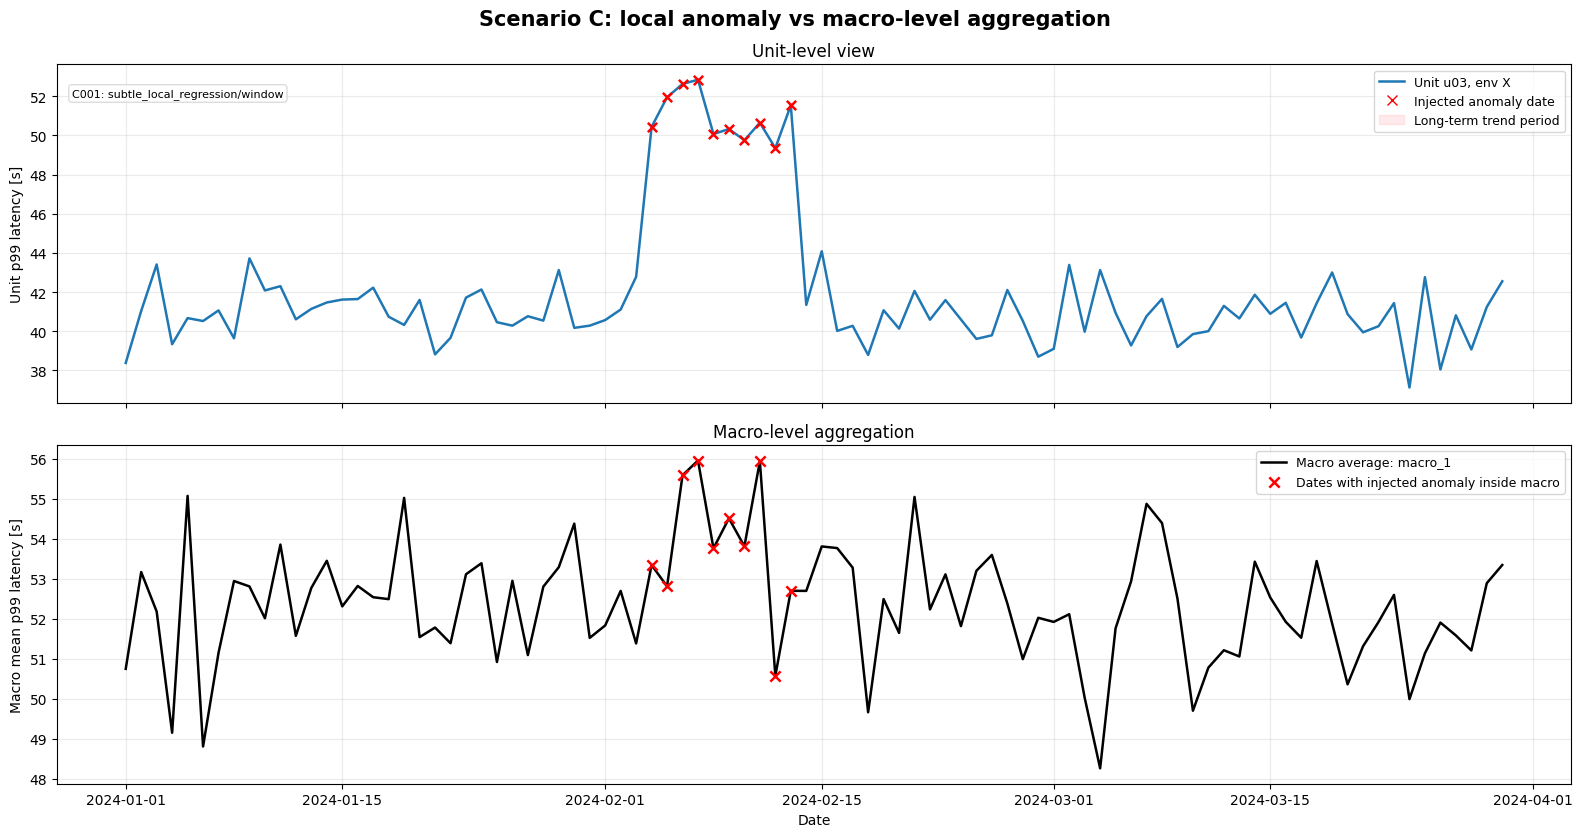

In [ ]:
def plot_unit_vs_macro_aggregation(data, scenario="C"):
    """
    Shows how a local unit-level anomaly can become much less visible
    after aggregation to macro level.
    """
    scenario_data = data[data["scenario"] == scenario].copy()

    anomaly_units = (
        scenario_data[
            (scenario_data[TRUTH_COL]) &
            (scenario_data["anomaly_scope"].isin(["unit", "segment"]))
        ][UNIT_COL]
        .drop_duplicates()
        .tolist()
    )

    if len(anomaly_units) == 0:
        print(f"No unit-level or segment-level anomalies found for scenario {scenario}.")
        return

    target_unit = anomaly_units[0]

    target_info = (
        scenario_data[scenario_data[UNIT_COL] == target_unit]
        [[MACRO_COL, SEGMENT_COL, UNIT_COL, ENV_COL]]
        .drop_duplicates()
        .iloc[0]
    )

    target_macro = target_info[MACRO_COL]

    unit_data = (
        scenario_data[scenario_data[UNIT_COL] == target_unit]
        .sort_values(DATE_COL)
        .copy()
    )

    macro_data = (
        scenario_data[scenario_data[MACRO_COL] == target_macro]
        .groupby(DATE_COL, as_index=False)
        .agg(
            macro_p99_mean=(VALUE_COL, "mean"),
            true_anomaly_points=(TRUTH_COL, "sum"),
        )
    )

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(16, 8.5),
        sharex=True,
    )

    fig.suptitle(
        f"Scenario {scenario}: local anomaly vs macro-level aggregation",
        fontsize=15,
        fontweight="bold",
    )

    # Unit-level view
    add_trend_spans(axes[0], unit_data)

    axes[0].plot(
        unit_data[DATE_COL],
        unit_data[VALUE_COL],
        color=ENV_COLOR[target_info[ENV_COL]],
        linewidth=1.8,
        label=f"Unit {target_unit}, env {target_info[ENV_COL]}",
        zorder=2,
    )

    add_short_anomaly_markers(axes[0], unit_data)

    axes[0].set_ylabel("Unit p99 latency [s]")
    axes[0].set_title("Unit-level view")
    axes[0].grid(True, alpha=0.25)

    unit_event_summary = get_event_summary(unit_data)

    if unit_event_summary:
        axes[0].text(
            0.01,
            0.93,
            unit_event_summary,
            transform=axes[0].transAxes,
            fontsize=8,
            verticalalignment="top",
            bbox=dict(
                boxstyle="round",
                facecolor="white",
                alpha=0.78,
                edgecolor="lightgray",
            ),
        )

    # Macro-level view
    axes[1].plot(
        macro_data[DATE_COL],
        macro_data["macro_p99_mean"],
        color="black",
        linewidth=1.8,
        label=f"Macro average: {target_macro}",
        zorder=2,
    )

    anomaly_dates = macro_data[macro_data["true_anomaly_points"] > 0]

    axes[1].scatter(
        anomaly_dates[DATE_COL],
        anomaly_dates["macro_p99_mean"],
        color="red",
        marker="x",
        s=55,
        linewidths=1.8,
        label="Dates with injected anomaly inside macro",
        zorder=5,
    )

    axes[1].set_ylabel("Macro mean p99 latency [s]")
    axes[1].set_title("Macro-level aggregation")
    axes[1].set_xlabel("Date")
    axes[1].grid(True, alpha=0.25)

    short_marker = mlines.Line2D(
        [],
        [],
        color="red",
        marker="x",
        linestyle="None",
        markersize=7,
        label="Injected anomaly date",
    )

    trend_patch = mpatches.Patch(
        color="red",
        alpha=0.08,
        label="Long-term trend period",
    )

    axes[0].legend(
        handles=axes[0].get_legend_handles_labels()[0] + [short_marker, trend_patch],
        fontsize=9,
        loc="upper right",
    )

    axes[1].legend(fontsize=9, loc="upper right")

    plt.tight_layout()
    plt.savefig(
        f"scenario_{scenario}_unit_vs_macro_aggregation_v2.png",
        dpi=150,
        bbox_inches="tight",
    )
    plt.show()

plot_unit_vs_macro_aggregation(all_df, scenario="C")

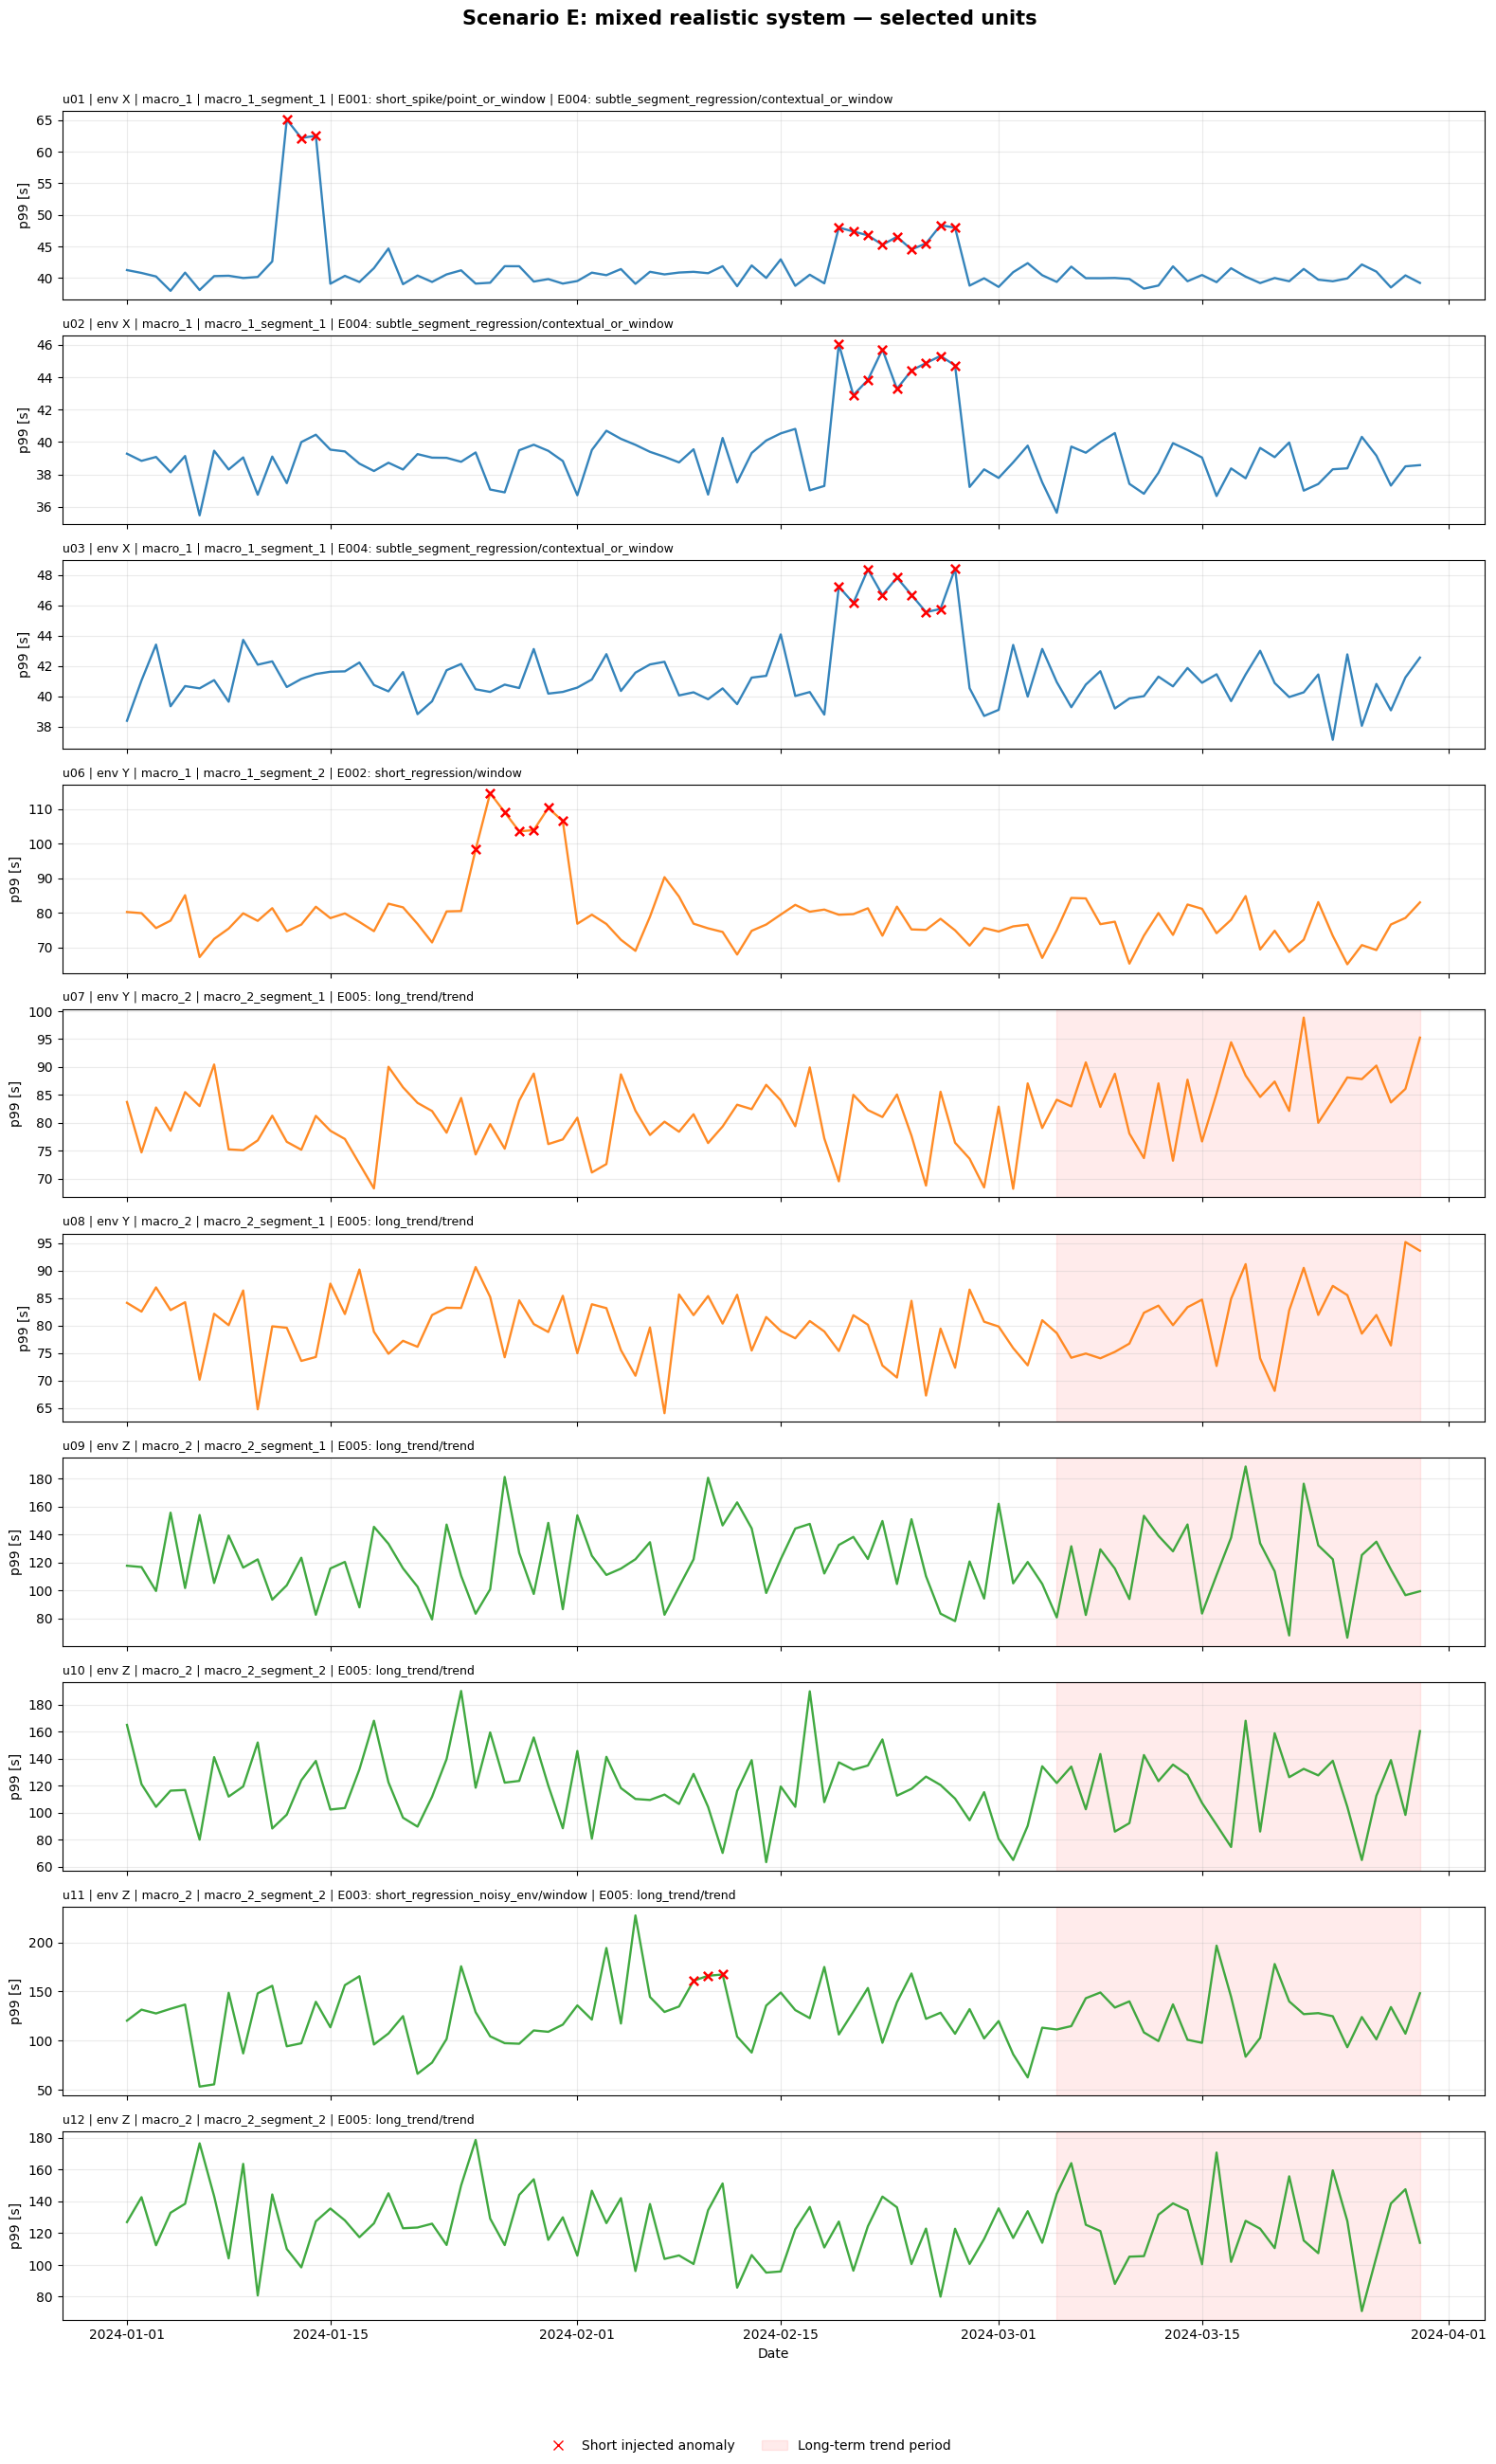

In [ ]:
def plot_mixed_scenario_units(data, scenario="E"):
    """
    Focused visualization for the mixed realistic scenario.

    Shows units that contain injected anomalies plus a few noisy Z units.
    """
    scenario_data = data[data["scenario"] == scenario].copy()

    anomaly_units = (
        scenario_data[scenario_data[TRUTH_COL]]
        [UNIT_COL]
        .drop_duplicates()
        .tolist()
    )

    # Add one extra noisy Z unit without true anomaly if available.
    z_non_anomaly_units = (
        scenario_data[
            (scenario_data[ENV_COL] == "Z") &
            (~scenario_data[UNIT_COL].isin(anomaly_units))
        ][UNIT_COL]
        .drop_duplicates()
        .tolist()
    )

    selected_units = anomaly_units.copy()

    if len(z_non_anomaly_units) > 0:
        selected_units.append(z_non_anomaly_units[0])

    selected_units = sorted(
        selected_units,
        key=lambda x: int(x.replace("u", ""))
    )

    n_units = len(selected_units)

    fig, axes = plt.subplots(
        n_units,
        1,
        figsize=(16, 2.6 * n_units),
        sharex=True,
    )

    if n_units == 1:
        axes = [axes]

    fig.suptitle(
        f"Scenario {scenario}: mixed realistic system — selected units",
        fontsize=15,
        fontweight="bold",
        y=0.995,
    )

    for ax, unit in zip(axes, selected_units):
        unit_data = (
            scenario_data[scenario_data[UNIT_COL] == unit]
            .sort_values(DATE_COL)
            .copy()
        )

        env = unit_data[ENV_COL].iloc[0]
        macro = unit_data[MACRO_COL].iloc[0]
        segment = unit_data[SEGMENT_COL].iloc[0]

        add_trend_spans(ax, unit_data)

        ax.plot(
            unit_data[DATE_COL],
            unit_data[VALUE_COL],
            color=ENV_COLOR[env],
            linewidth=1.7,
            alpha=0.90,
            zorder=2,
        )

        add_short_anomaly_markers(ax, unit_data)

        event_summary = get_event_summary(unit_data)

        title = f"{unit} | env {env} | {macro} | {segment}"

        if event_summary:
            title += f" | {event_summary}"
        else:
            title += " | no injected anomaly"

        ax.set_title(title, fontsize=9, loc="left")
        ax.set_ylabel("p99 [s]")
        ax.grid(True, alpha=0.25)

    axes[-1].set_xlabel("Date")

    short_marker = mlines.Line2D(
        [],
        [],
        color="red",
        marker="x",
        linestyle="None",
        markersize=7,
        label="Short injected anomaly",
    )

    trend_patch = mpatches.Patch(
        color="red",
        alpha=0.08,
        label="Long-term trend period",
    )

    fig.legend(
        handles=[short_marker, trend_patch],
        loc="lower center",
        ncol=2,
        fontsize=10,
        frameon=False,
    )

    plt.tight_layout(rect=[0, 0.035, 1, 0.98])
    plt.savefig(
        f"scenario_{scenario}_mixed_units_v2.png",
        dpi=150,
        bbox_inches="tight",
    )
    plt.show()

plot_mixed_scenario_units(all_df, scenario="E")

### Short-term anomaly detection: baseline methods

In [ ]:
# ── Short-term detection configuration ───────────────────────────────────────

SHORT_SCENARIOS = ["A", "B", "C", "E"]

VALUE_COL   = "p99_latency_seconds"
DATE_COL    = "date"
UNIT_COL    = "unit_id"
ENV_COL     = "env_type"
SEGMENT_COL = "segment_id"
MACRO_COL   = "macro_id"
TRUTH_COL   = "is_injected_anomaly"

SHORT_OUTPUT_FILE = "short_term_detection_results.csv"

METHODS = ["zscore", "robust_zscore", "iqr"]

DEFAULT_SHORT_PARAMS = {
    "window": 14,
    "min_periods": 7,
    "z_threshold": 2.5,
    "robust_threshold": 3.0,
    "iqr_multiplier": 1.5,
}

# ── Short-term anomaly detection methods ─────────────────────────────────────

def rolling_zscore(series, window=14, min_periods=7, threshold=2.5):
    s = series.astype(float)

    rolling_mean = s.shift(1).rolling(
        window=window,
        min_periods=min_periods
    ).mean()

    rolling_std = s.shift(1).rolling(
        window=window,
        min_periods=min_periods
    ).std(ddof=0)

    rolling_std = rolling_std.replace(0, np.nan)

    score = (s - rolling_mean) / rolling_std
    flag = score > threshold

    return pd.DataFrame({
        "baseline_center": rolling_mean,
        "baseline_scale": rolling_std,
        "score": score,
        "is_anomaly": flag.fillna(False),
    })


def rolling_robust_zscore(series, window=14, min_periods=7, threshold=3.0):
    s = series.astype(float)

    rolling_median = s.shift(1).rolling(
        window=window,
        min_periods=min_periods
    ).median()

    def mad(x):
        med = np.median(x)
        return np.median(np.abs(x - med))

    rolling_mad = s.shift(1).rolling(
        window=window,
        min_periods=min_periods
    ).apply(mad, raw=True)

    robust_scale = 1.4826 * rolling_mad
    robust_scale = robust_scale.replace(0, np.nan)

    score = (s - rolling_median) / robust_scale
    flag = score > threshold

    return pd.DataFrame({
        "baseline_center": rolling_median,
        "baseline_scale": robust_scale,
        "score": score,
        "is_anomaly": flag.fillna(False),
    })


def rolling_iqr_rule(series, window=14, min_periods=7, multiplier=1.5):
    s = series.astype(float)

    q1 = s.shift(1).rolling(
        window=window,
        min_periods=min_periods
    ).quantile(0.25)

    q3 = s.shift(1).rolling(
        window=window,
        min_periods=min_periods
    ).quantile(0.75)

    iqr = q3 - q1
    upper_fence = q3 + multiplier * iqr

    denom = iqr.replace(0, np.nan)
    score = (s - upper_fence) / denom

    flag = s > upper_fence

    return pd.DataFrame({
        "baseline_center": q3,
        "baseline_scale": iqr,
        "upper_fence": upper_fence,
        "score": score,
        "is_anomaly": flag.fillna(False),
    })

# ── Apply detectors by unit ──────────────────────────────────────────────────

def apply_detector_by_group(
    data,
    group_cols,
    value_col,
    method_name,
    window=14,
    min_periods=7,
    z_threshold=2.5,
    robust_threshold=3.0,
    iqr_multiplier=1.5,
):
    out_frames = []

    for _, grp in data.groupby(group_cols, sort=False):
        grp = grp.sort_values(DATE_COL).copy()

        if method_name == "zscore":
            det = rolling_zscore(
                grp[value_col],
                window=window,
                min_periods=min_periods,
                threshold=z_threshold,
            )

        elif method_name == "robust_zscore":
            det = rolling_robust_zscore(
                grp[value_col],
                window=window,
                min_periods=min_periods,
                threshold=robust_threshold,
            )

        elif method_name == "iqr":
            det = rolling_iqr_rule(
                grp[value_col],
                window=window,
                min_periods=min_periods,
                multiplier=iqr_multiplier,
            )

        else:
            raise ValueError(f"Unknown method_name: {method_name}")

        det = det.add_prefix(f"{method_name}_")

        grp = pd.concat(
            [grp.reset_index(drop=True), det.reset_index(drop=True)],
            axis=1,
        )

        out_frames.append(grp)

    return (
        pd.concat(out_frames, axis=0)
        .sort_values(group_cols + [DATE_COL])
        .reset_index(drop=True)
    )


def run_short_term_detection(data, params=None):
    if params is None:
        params = DEFAULT_SHORT_PARAMS

    out = data.copy()
    out[DATE_COL] = pd.to_datetime(out[DATE_COL])
    out = out.sort_values([UNIT_COL, DATE_COL]).reset_index(drop=True)
    out[TRUTH_COL] = out[TRUTH_COL].astype(bool)

    out = apply_detector_by_group(
        out,
        group_cols=[UNIT_COL],
        value_col=VALUE_COL,
        method_name="zscore",
        window=params["window"],
        min_periods=params["min_periods"],
        z_threshold=params["z_threshold"],
    )

    out = apply_detector_by_group(
        out,
        group_cols=[UNIT_COL],
        value_col=VALUE_COL,
        method_name="robust_zscore",
        window=params["window"],
        min_periods=params["min_periods"],
        robust_threshold=params["robust_threshold"],
    )

    out = apply_detector_by_group(
        out,
        group_cols=[UNIT_COL],
        value_col=VALUE_COL,
        method_name="iqr",
        window=params["window"],
        min_periods=params["min_periods"],
        iqr_multiplier=params["iqr_multiplier"],
    )

    return out

# ── Point-level evaluation ───────────────────────────────────────────────────

def evaluate_method_point_level(data, method_name):
    flag_col = f"{method_name}_is_anomaly"

    y_true = data[TRUTH_COL].astype(bool)
    y_pred = data[flag_col].fillna(False).astype(bool)

    tp = int((y_true & y_pred).sum())
    fp = int((~y_true & y_pred).sum())
    fn = int((y_true & ~y_pred).sum())
    tn = int((~y_true & ~y_pred).sum())

    precision = tp / (tp + fp) if (tp + fp) else np.nan
    recall = tp / (tp + fn) if (tp + fn) else np.nan
    f1 = (
        2 * precision * recall / (precision + recall)
        if pd.notna(precision) and pd.notna(recall) and (precision + recall)
        else np.nan
    )

    fpr = fp / (fp + tn) if (fp + tn) else np.nan
    fnr = fn / (fn + tp) if (fn + tp) else np.nan

    return {
        "method": method_name,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "False Positive Rate": fpr,
        "False Negative Rate": fnr,
        "detected_points": int(y_pred.sum()),
        "true_anomaly_points": int(y_true.sum()),
    }


def build_point_level_comparison(data):
    rows = []

    for method in METHODS:
        rows.append(evaluate_method_point_level(data, method))

    return pd.DataFrame(rows)

# ── Environment-level evaluation ─────────────────────────────────────────────

def build_environment_metrics(data):
    rows = []

    for method in METHODS:
        flag_col = f"{method}_is_anomaly"

        for env, grp in data.groupby(ENV_COL):
            y_true = grp[TRUTH_COL].astype(bool)
            y_pred = grp[flag_col].fillna(False).astype(bool)

            tp = int((y_true & y_pred).sum())
            fp = int((~y_true & y_pred).sum())
            fn = int((y_true & ~y_pred).sum())
            tn = int((~y_true & ~y_pred).sum())

            precision = tp / (tp + fp) if (tp + fp) else np.nan
            recall = tp / (tp + fn) if (tp + fn) else np.nan
            f1 = (
                2 * precision * recall / (precision + recall)
                if pd.notna(precision) and pd.notna(recall) and (precision + recall)
                else np.nan
            )

            rows.append({
                "method": method,
                ENV_COL: env,
                "TP": tp,
                "FP": fp,
                "FN": fn,
                "TN": tn,
                "Precision": precision,
                "Recall": recall,
                "F1": f1,
                "detected_points": int(y_pred.sum()),
                "true_anomaly_points": int(y_true.sum()),
            })

    return pd.DataFrame(rows)

# ── Event-level evaluation ───────────────────────────────────────────────────

def evaluate_method_event_level(data, method_name):
    flag_col = f"{method_name}_is_anomaly"

    true_events = (
        data[data[TRUTH_COL] & (data["anomaly_event_id"] != "none")]
        ["anomaly_event_id"]
        .drop_duplicates()
        .tolist()
    )

    detected_events = []

    for event_id in true_events:
        event_data = data[data["anomaly_event_id"] == event_id]

        was_detected = event_data[flag_col].fillna(False).astype(bool).any()

        detected_events.append({
            "anomaly_event_id": event_id,
            "method": method_name,
            "event_detected": was_detected,
            "event_points": len(event_data),
            "detected_points_inside_event": int(
                event_data[flag_col].fillna(False).astype(bool).sum()
            ),
            "anomaly_type": event_data["anomaly_type"].iloc[0],
            "anomaly_scope": event_data["anomaly_scope"].iloc[0],
            "env_types": ",".join(sorted(event_data[ENV_COL].drop_duplicates())),
        })

    return pd.DataFrame(detected_events)


def build_event_level_comparison(data):
    frames = []

    for method in METHODS:
        frames.append(evaluate_method_event_level(data, method))

    if len(frames) == 0:
        return pd.DataFrame()

    return pd.concat(frames, ignore_index=True)

### Short-term anomaly detection: parameter tuning

In [ ]:
# ── Parameter grid for short-term methods ────────────────────────────────────

SHORT_PARAM_GRID = [
    {
        "window": window,
        "min_periods": min_periods,
        "z_threshold": z_threshold,
        "robust_threshold": robust_threshold,
        "iqr_multiplier": iqr_multiplier,
    }
    for window in [7, 14, 21]
    for min_periods in [5, 7, 10]
    for z_threshold in [1.8, 2.0, 2.5, 3.0]
    for robust_threshold in [1.8, 2.0, 2.5, 3.0]
    for iqr_multiplier in [0.7, 1.0, 1.5, 2.0]
    if min_periods <= window
]

print(f"Number of parameter combinations: {len(SHORT_PARAM_GRID)}")

# ── Helper: prepare short-term ground truth ──────────────────────────────────

SHORT_TERM_ANOMALY_TYPES = [
    "short_spike",
    "short_regression",
    "short_regression_noisy_env",
    "subtle_local_regression",
    "subtle_segment_regression",
]


def prepare_short_term_truth(data):
    """
    Creates a copy of the dataset where only short-term anomaly types
    are treated as true anomalies.

    This is important for Scenario E, because it contains long-term trends
    that should not dominate the evaluation of short-term methods.
    """
    out = data.copy()

    out[TRUTH_COL] = (
        out[TRUTH_COL].astype(bool)
        & out["anomaly_type"].isin(SHORT_TERM_ANOMALY_TYPES)
    )

    return out

# ── Grid search for one seed ─────────────────────────────────────────────────

def run_short_term_grid_search_single_seed(
    scenarios=["A", "B", "C", "E"],
    seed=42,
    param_grid=SHORT_PARAM_GRID,
    short_term_truth_only=True,
    save_output=True,
):
    rows = []

    total_runs = len(param_grid) * len(scenarios)
    run_id = 1

    for params in param_grid:
        for scenario in scenarios:
            if run_id % 50 == 0:
                print(
                    f"Run {run_id}/{total_runs} | "
                )

            df_scenario = generate_latency_dataset(
                scenario=scenario,
                seed=seed,
                save_csv=False,
            )

            if short_term_truth_only:
                df_scenario = prepare_short_term_truth(df_scenario)

            stage = run_short_term_detection(
                df_scenario,
                params=params,
            )

            comparison = build_point_level_comparison(stage)

            for _, result_row in comparison.iterrows():
                result = result_row.to_dict()

                result["scenario"] = scenario
                result["seed"] = seed

                result["window"] = params["window"]
                result["min_periods"] = params["min_periods"]
                result["z_threshold"] = params["z_threshold"]
                result["robust_threshold"] = params["robust_threshold"]
                result["iqr_multiplier"] = params["iqr_multiplier"]

                rows.append(result)

            run_id += 1

    grid_results = pd.DataFrame(rows)

    if save_output:
        grid_results.to_csv(
            "short_term_grid_search_single_seed.csv",
            index=False,
        )
        print("Saved: short_term_grid_search_single_seed.csv")

    return grid_results

grid_results = run_short_term_grid_search_single_seed(
    scenarios=["A", "B", "C", "E"],
    seed=42,
    short_term_truth_only=True,
    save_output=True,
)

display(grid_results.head())

# ── Best parameter sets per method ───────────────────────────────────────────

def summarize_grid_search_by_method(grid_results):
    summaries = []

    # Z-score
    zscore_summary = (
        grid_results[grid_results["method"] == "zscore"]
        .groupby(
            ["method", "window", "min_periods", "z_threshold"],
            as_index=False,
        )
        .agg(
            mean_precision=("Precision", "mean"),
            mean_recall=("Recall", "mean"),
            mean_f1=("F1", "mean"),
            mean_fpr=("False Positive Rate", "mean"),
            mean_fnr=("False Negative Rate", "mean"),
            total_tp=("TP", "sum"),
            total_fp=("FP", "sum"),
            total_fn=("FN", "sum"),
        )
    )

    summaries.append(zscore_summary)

    # Robust z-score
    robust_summary = (
        grid_results[grid_results["method"] == "robust_zscore"]
        .groupby(
            ["method", "window", "min_periods", "robust_threshold"],
            as_index=False,
        )
        .agg(
            mean_precision=("Precision", "mean"),
            mean_recall=("Recall", "mean"),
            mean_f1=("F1", "mean"),
            mean_fpr=("False Positive Rate", "mean"),
            mean_fnr=("False Negative Rate", "mean"),
            total_tp=("TP", "sum"),
            total_fp=("FP", "sum"),
            total_fn=("FN", "sum"),
        )
    )

    summaries.append(robust_summary)

    # IQR
    iqr_summary = (
        grid_results[grid_results["method"] == "iqr"]
        .groupby(
            ["method", "window", "min_periods", "iqr_multiplier"],
            as_index=False,
        )
        .agg(
            mean_precision=("Precision", "mean"),
            mean_recall=("Recall", "mean"),
            mean_f1=("F1", "mean"),
            mean_fpr=("False Positive Rate", "mean"),
            mean_fnr=("False Negative Rate", "mean"),
            total_tp=("TP", "sum"),
            total_fp=("FP", "sum"),
            total_fn=("FN", "sum"),
        )
    )

    summaries.append(iqr_summary)

    return summaries


zscore_summary, robust_summary, iqr_summary = summarize_grid_search_by_method(
    grid_results
)

print("Best zscore parameter sets:")
display(
    zscore_summary
    .sort_values(["mean_f1", "mean_fpr"], ascending=[False, True])
    .head(10)
)

print("Best robust_zscore parameter sets:")
display(
    robust_summary
    .sort_values(["mean_f1", "mean_fpr"], ascending=[False, True])
    .head(10)
)

print("Best IQR parameter sets:")
display(
    iqr_summary
    .sort_values(["mean_f1", "mean_fpr"], ascending=[False, True])
    .head(10)
)

# ── Compact top results table ────────────────────────────────────────────────

def build_top_parameter_table(
    zscore_summary,
    robust_summary,
    iqr_summary,
    top_n=5,
):
    z_top = (
        zscore_summary
        .sort_values(["mean_f1", "mean_fpr"], ascending=[False, True])
        .head(top_n)
    )

    robust_top = (
        robust_summary
        .sort_values(["mean_f1", "mean_fpr"], ascending=[False, True])
        .head(top_n)
    )

    iqr_top = (
        iqr_summary
        .sort_values(["mean_f1", "mean_fpr"], ascending=[False, True])
        .head(top_n)
    )

    top_table = pd.concat(
        [z_top, robust_top, iqr_top],
        ignore_index=True,
        sort=False,
    )

    cols = [
        "method",
        "window",
        "min_periods",
        "z_threshold",
        "robust_threshold",
        "iqr_multiplier",
        "mean_precision",
        "mean_recall",
        "mean_f1",
        "mean_fpr",
        "mean_fnr",
        "total_tp",
        "total_fp",
        "total_fn",
    ]

    cols = [c for c in cols if c in top_table.columns]

    return top_table[cols]


top_params_table = build_top_parameter_table(
    zscore_summary,
    robust_summary,
    iqr_summary,
    top_n=5,
)

display(top_params_table)

top_params_table.to_csv(
    "short_term_top_parameter_sets.csv",
    index=False,
)

print("Saved: short_term_top_parameter_sets.csv")

Number of parameter combinations: 512
Run 50/2048 | 
Run 100/2048 | 
Run 150/2048 | 
Run 200/2048 | 
Run 250/2048 | 
Run 300/2048 | 
Run 350/2048 | 
Run 400/2048 | 
Run 450/2048 | 
Run 500/2048 | 
Run 550/2048 | 
Run 600/2048 | 
Run 650/2048 | 
Run 700/2048 | 
Run 750/2048 | 
Run 800/2048 | 
Run 850/2048 | 
Run 900/2048 | 
Run 950/2048 | 
Run 1000/2048 | 
Run 1050/2048 | 
Run 1100/2048 | 
Run 1150/2048 | 
Run 1200/2048 | 
Run 1250/2048 | 
Run 1300/2048 | 
Run 1350/2048 | 
Run 1400/2048 | 
Run 1450/2048 | 
Run 1500/2048 | 
Run 1550/2048 | 
Run 1600/2048 | 
Run 1650/2048 | 
Run 1700/2048 | 
Run 1750/2048 | 
Run 1800/2048 | 
Run 1850/2048 | 
Run 1900/2048 | 
Run 1950/2048 | 
Run 2000/2048 | 
Saved: short_term_grid_search_single_seed.csv


,method,TP,FP,FN,TN,Precision,Recall,F1,False Positive Rate,False Negative Rate,detected_points,true_anomaly_points,scenario,seed,window,min_periods,z_threshold,robust_threshold,iqr_multiplier
0,zscore,2,80,6,992,0.024390,0.250000,0.044444,0.074627,0.750000,82,8,A,42,7,5,1.8,1.8,0.7
1,robust_zscore,4,88,4,984,0.043478,0.500000,0.080000,0.082090,0.500000,92,8,A,42,7,5,1.8,1.8,0.7
2,iqr,3,132,5,940,0.022222,0.375000,0.041958,0.123134,0.625000,135,8,A,42,7,5,1.8,1.8,0.7
3,zscore,5,80,7,988,0.058824,0.416667,0.103093,0.074906,0.583333,85,12,B,42,7,5,1.8,1.8,0.7
4,robust_zscore,8,86,4,982,0.085106,0.666667,0.150943,0.080524,0.333333,94,12,B,42,7,5,1.8,1.8,0.7


Best zscore parameter sets:


,method,window,min_periods,z_threshold,mean_precision,mean_recall,mean_f1,mean_fpr,mean_fnr,total_tp,total_fp,total_fn
30,zscore,21,10,2.5,0.362027,0.435417,0.381581,0.010147,0.564583,416,688,704
26,zscore,21,7,2.5,0.345188,0.435417,0.369873,0.010848,0.564583,416,736,704
22,zscore,21,5,2.5,0.341220,0.435417,0.368556,0.011088,0.564583,416,752,704
31,zscore,21,10,3.0,0.534524,0.270833,0.355858,0.003311,0.729167,272,224,848
27,zscore,21,7,3.0,0.476190,0.270833,0.339001,0.004012,0.729167,272,272,848
23,zscore,21,5,3.0,0.466667,0.270833,0.337654,0.004252,0.729167,272,288,848
29,zscore,21,10,2.0,0.234288,0.529167,0.310282,0.023793,0.470833,544,1616,576
25,zscore,21,7,2.0,0.219386,0.529167,0.294414,0.026136,0.470833,544,1776,576
21,zscore,21,5,2.0,0.211892,0.529167,0.287755,0.027318,0.470833,544,1856,576
28,zscore,21,10,1.8,0.181114,0.589583,0.261002,0.038820,0.410417,624,2640,496


Best robust_zscore parameter sets:


,method,window,min_periods,robust_threshold,mean_precision,mean_recall,mean_f1,mean_fpr,mean_fnr,total_tp,total_fp,total_fn
11,robust_zscore,14,5,3.0,0.472222,0.608333,0.513744,0.008726,0.391667,560,592,560
15,robust_zscore,14,7,3.0,0.472222,0.608333,0.513744,0.008726,0.391667,560,592,560
19,robust_zscore,14,10,3.0,0.472222,0.608333,0.513744,0.008726,0.391667,560,592,560
23,robust_zscore,21,5,3.0,0.549278,0.460417,0.495044,0.004493,0.539583,544,304,576
27,robust_zscore,21,7,3.0,0.549278,0.460417,0.495044,0.004493,0.539583,544,304,576
31,robust_zscore,21,10,3.0,0.549278,0.460417,0.495044,0.004493,0.539583,544,304,576
22,robust_zscore,21,5,2.5,0.376033,0.516667,0.426495,0.011075,0.483333,640,752,480
26,robust_zscore,21,7,2.5,0.376033,0.516667,0.426495,0.011075,0.483333,640,752,480
30,robust_zscore,21,10,2.5,0.376033,0.516667,0.426495,0.011075,0.483333,640,752,480
10,robust_zscore,14,5,2.5,0.271754,0.608333,0.351797,0.021176,0.391667,560,1440,560


Best IQR parameter sets:


,method,window,min_periods,iqr_multiplier,mean_precision,mean_recall,mean_f1,mean_fpr,mean_fnr,total_tp,total_fp,total_fn
31,iqr,21,10,2.0,0.682292,0.63125,0.654423,0.004507,0.36875,672,304,448
27,iqr,21,7,2.0,0.628632,0.63125,0.627744,0.005448,0.36875,672,368,448
23,iqr,21,5,2.0,0.619109,0.63125,0.623725,0.005929,0.36875,672,400,448
30,iqr,21,10,1.5,0.421528,0.65000,0.500172,0.012016,0.35000,720,816,400
19,iqr,14,10,2.0,0.502174,0.50000,0.488889,0.006369,0.50000,496,432,624
15,iqr,14,7,2.0,0.468277,0.50000,0.470591,0.007310,0.50000,496,496,624
11,iqr,14,5,2.0,0.457059,0.50000,0.467276,0.007791,0.50000,496,528,624
26,iqr,21,7,1.5,0.377588,0.65000,0.463992,0.014600,0.35000,720,992,400
22,iqr,21,5,1.5,0.345435,0.65000,0.438525,0.016963,0.35000,720,1152,400
18,iqr,14,10,1.5,0.261753,0.50625,0.326189,0.019534,0.49375,512,1328,608


,method,window,min_periods,z_threshold,robust_threshold,iqr_multiplier,mean_precision,mean_recall,mean_f1,mean_fpr,mean_fnr,total_tp,total_fp,total_fn
0,zscore,21,10,2.5,NaN,NaN,0.362027,0.435417,0.381581,0.010147,0.564583,416,688,704
1,zscore,21,7,2.5,NaN,NaN,0.345188,0.435417,0.369873,0.010848,0.564583,416,736,704
2,zscore,21,5,2.5,NaN,NaN,0.341220,0.435417,0.368556,0.011088,0.564583,416,752,704
3,zscore,21,10,3.0,NaN,NaN,0.534524,0.270833,0.355858,0.003311,0.729167,272,224,848
4,zscore,21,7,3.0,NaN,NaN,0.476190,0.270833,0.339001,0.004012,0.729167,272,272,848
5,robust_zscore,14,5,NaN,3.0,NaN,0.472222,0.608333,0.513744,0.008726,0.391667,560,592,560
6,robust_zscore,14,7,NaN,3.0,NaN,0.472222,0.608333,0.513744,0.008726,0.391667,560,592,560
7,robust_zscore,14,10,NaN,3.0,NaN,0.472222,0.608333,0.513744,0.008726,0.391667,560,592,560
8,robust_zscore,21,5,NaN,3.0,NaN,0.549278,0.460417,0.495044,0.004493,0.539583,544,304,576
9,robust_zscore,21,7,NaN,3.0,NaN,0.549278,0.460417,0.495044,0.004493,0.539583,544,304,576


Saved: short_term_top_parameter_sets.csv


### Final short-term benchmark

In [ ]:
# ── Final short-term method parameters ───────────────────────────────────────

FINAL_METHOD_PARAMS = {
    "zscore": {
        "window": 21,
        "min_periods": 10,
        "z_threshold": 2.5,
        "robust_threshold": 3.0,   # unused for zscore
        "iqr_multiplier": 2.0,     # unused for zscore
    },
    "robust_zscore": {
        "window": 14,
        "min_periods": 10,
        "z_threshold": 2.5,        # unused for robust_zscore
        "robust_threshold": 3.0,
        "iqr_multiplier": 2.0,     # unused for robust_zscore
    },
    "iqr": {
        "window": 21,
        "min_periods": 10,
        "z_threshold": 2.5,        # unused for iqr
        "robust_threshold": 3.0,   # unused for iqr
        "iqr_multiplier": 2.0,
    },
}

FINAL_SCENARIOS = ["A", "B", "C", "E"]
FINAL_SEEDS = range(1, 21)

# ── Run a single detector with method-specific parameters ────────────────────

def run_single_short_term_detector(data, method_name, params):
    """
    Runs only one selected short-term detector using method-specific parameters.
    """
    out = data.copy()
    out[DATE_COL] = pd.to_datetime(out[DATE_COL])
    out = out.sort_values([UNIT_COL, DATE_COL]).reset_index(drop=True)
    out[TRUTH_COL] = out[TRUTH_COL].astype(bool)

    out = apply_detector_by_group(
        out,
        group_cols=[UNIT_COL],
        value_col=VALUE_COL,
        method_name=method_name,
        window=params["window"],
        min_periods=params["min_periods"],
        z_threshold=params["z_threshold"],
        robust_threshold=params["robust_threshold"],
        iqr_multiplier=params["iqr_multiplier"],
    )

    return out

# ── Final short-term benchmark ───────────────────────────────────────────────

def run_final_short_term_benchmark(
    scenarios=FINAL_SCENARIOS,
    seeds=FINAL_SEEDS,
    final_method_params=FINAL_METHOD_PARAMS,
    short_term_truth_only=True,
    save_outputs=True,
):
    seeds = list(seeds)

    all_outputs = []
    point_results = []
    env_results = []
    event_results = []

    total_runs = len(seeds) * len(scenarios) * len(final_method_params)
    run_id = 1

    # Precompute datasets once.
    datasets = {}

    for seed in seeds:
        for scenario in scenarios:

            df_scenario = generate_latency_dataset(
                scenario=scenario,
                seed=seed,
                save_csv=False,
            )

            if short_term_truth_only:
                df_scenario = prepare_short_term_truth(df_scenario)

            datasets[(seed, scenario)] = df_scenario.copy()

    # Run final benchmark.
    for seed in seeds:
        for scenario in scenarios:
            for method_name, params in final_method_params.items():
                if run_id % 50 == 0:
                    print(
                        f"Run {run_id}/{total_runs} | "
                    )

                df_scenario = datasets[(seed, scenario)].copy()

                stage = run_single_short_term_detector(
                    data=df_scenario,
                    method_name=method_name,
                    params=params,
                )

                stage["seed"] = seed
                stage["scenario"] = scenario
                stage["method_evaluated"] = method_name

                # Point-level summary
                point_df = evaluate_method_point_level(
                    stage,
                    method_name=method_name,
                )

                point_df = pd.DataFrame([point_df])
                point_df["seed"] = seed
                point_df["scenario"] = scenario
                point_df["window"] = params["window"]
                point_df["min_periods"] = params["min_periods"]
                point_df["z_threshold"] = params["z_threshold"]
                point_df["robust_threshold"] = params["robust_threshold"]
                point_df["iqr_multiplier"] = params["iqr_multiplier"]

                # Environment-level summary for this one method
                env_df = build_environment_metrics_for_single_method(
                    stage,
                    method_name=method_name,
                )
                env_df["seed"] = seed
                env_df["scenario"] = scenario
                env_df["window"] = params["window"]
                env_df["min_periods"] = params["min_periods"]
                env_df["z_threshold"] = params["z_threshold"]
                env_df["robust_threshold"] = params["robust_threshold"]
                env_df["iqr_multiplier"] = params["iqr_multiplier"]

                # Event-level summary for this one method
                event_df = evaluate_method_event_level(
                    stage,
                    method_name=method_name,
                )
                event_df["seed"] = seed
                event_df["scenario"] = scenario
                event_df["window"] = params["window"]
                event_df["min_periods"] = params["min_periods"]
                event_df["z_threshold"] = params["z_threshold"]
                event_df["robust_threshold"] = params["robust_threshold"]
                event_df["iqr_multiplier"] = params["iqr_multiplier"]

                all_outputs.append(stage)
                point_results.append(point_df)
                env_results.append(env_df)
                event_results.append(event_df)

                run_id += 1

    final_full_output = pd.concat(all_outputs, ignore_index=True)
    final_point_summary = pd.concat(point_results, ignore_index=True)
    final_env_summary = pd.concat(env_results, ignore_index=True)
    final_event_summary = pd.concat(event_results, ignore_index=True)

    if save_outputs:
        final_full_output.to_csv(
            "final_short_term_detection_full_output.csv",
            index=False,
        )

        final_point_summary.to_csv(
            "final_short_term_point_level_by_seed.csv",
            index=False,
        )

        final_env_summary.to_csv(
            "final_short_term_environment_by_seed.csv",
            index=False,
        )

        final_event_summary.to_csv(
            "final_short_term_event_level_by_seed.csv",
            index=False,
        )

        print("\nSaved:")
        print("  final_short_term_detection_full_output.csv")
        print("  final_short_term_point_level_by_seed.csv")
        print("  final_short_term_environment_by_seed.csv")
        print("  final_short_term_event_level_by_seed.csv")

    return (
        final_full_output,
        final_point_summary,
        final_env_summary,
        final_event_summary,
    )

# ── Environment-level metrics for one method ─────────────────────────────────

def build_environment_metrics_for_single_method(data, method_name):
    flag_col = f"{method_name}_is_anomaly"
    rows = []

    for env, grp in data.groupby(ENV_COL):
        y_true = grp[TRUTH_COL].astype(bool)
        y_pred = grp[flag_col].fillna(False).astype(bool)

        tp = int((y_true & y_pred).sum())
        fp = int((~y_true & y_pred).sum())
        fn = int((y_true & ~y_pred).sum())
        tn = int((~y_true & ~y_pred).sum())

        precision = tp / (tp + fp) if (tp + fp) else np.nan
        recall = tp / (tp + fn) if (tp + fn) else np.nan
        f1 = (
            2 * precision * recall / (precision + recall)
            if pd.notna(precision) and pd.notna(recall) and (precision + recall)
            else np.nan
        )

        fpr = fp / (fp + tn) if (fp + tn) else np.nan
        fnr = fn / (fn + tp) if (fn + tp) else np.nan

        rows.append({
            "method": method_name,
            ENV_COL: env,
            "TP": tp,
            "FP": fp,
            "FN": fn,
            "TN": tn,
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
            "False Positive Rate": fpr,
            "False Negative Rate": fnr,
            "detected_points": int(y_pred.sum()),
            "true_anomaly_points": int(y_true.sum()),
        })

    return pd.DataFrame(rows)

final_full_output, final_point_summary, final_env_summary, final_event_summary = run_final_short_term_benchmark(
    scenarios=["A", "B", "C", "E"],
    seeds=range(1, 21),
    short_term_truth_only=True,
    save_outputs=True,
)

# ── Final benchmark aggregated summary ───────────────────────────────────────

def aggregate_final_point_summary(final_point_summary):
    return (
        final_point_summary
        .groupby(["scenario", "method"], as_index=False)
        .agg(
            mean_precision=("Precision", "mean"),
            std_precision=("Precision", "std"),
            mean_recall=("Recall", "mean"),
            std_recall=("Recall", "std"),
            mean_f1=("F1", "mean"),
            std_f1=("F1", "std"),
            mean_fpr=("False Positive Rate", "mean"),
            std_fpr=("False Positive Rate", "std"),
            mean_fnr=("False Negative Rate", "mean"),
            std_fnr=("False Negative Rate", "std"),
            total_tp=("TP", "sum"),
            total_fp=("FP", "sum"),
            total_fn=("FN", "sum"),
            total_detected_points=("detected_points", "sum"),
            total_true_anomaly_points=("true_anomaly_points", "sum"),
        )
        .sort_values(["scenario", "mean_f1"], ascending=[True, False])
        .reset_index(drop=True)
    )


def aggregate_final_environment_summary(final_env_summary):
    return (
        final_env_summary
        .groupby(["scenario", ENV_COL, "method"], as_index=False)
        .agg(
            mean_precision=("Precision", "mean"),
            mean_recall=("Recall", "mean"),
            mean_f1=("F1", "mean"),
            mean_fpr=("False Positive Rate", "mean"),
            mean_fnr=("False Negative Rate", "mean"),
            total_tp=("TP", "sum"),
            total_fp=("FP", "sum"),
            total_fn=("FN", "sum"),
            total_detected_points=("detected_points", "sum"),
            total_true_anomaly_points=("true_anomaly_points", "sum"),
        )
        .sort_values(["scenario", ENV_COL, "mean_f1"], ascending=[True, True, False])
        .reset_index(drop=True)
    )


def aggregate_final_event_summary(final_event_summary):
    event_summary = final_event_summary.copy()
    event_summary["event_detected"] = event_summary["event_detected"].astype(bool)

    return (
        event_summary
        .groupby(["scenario", "method"], as_index=False)
        .agg(
            detected_events=("event_detected", "sum"),
            total_events=("event_detected", "count"),
            mean_detected_points_inside_event=("detected_points_inside_event", "mean"),
        )
        .assign(
            event_recall=lambda x: x["detected_events"] / x["total_events"]
        )
        .sort_values(["scenario", "event_recall"], ascending=[True, False])
        .reset_index(drop=True)
    )

final_point_agg = aggregate_final_point_summary(final_point_summary)
final_env_agg = aggregate_final_environment_summary(final_env_summary)
final_event_agg = aggregate_final_event_summary(final_event_summary)

# ── Simplified final point-level table for report ────────────────────────────

def build_simple_final_table(final_point_agg):
    simple_table = final_point_agg[
        [
            "scenario",
            "method",
            "mean_precision",
            "mean_recall",
            "mean_f1",
            "mean_fpr",
        ]
    ].copy()

    simple_table = simple_table.rename(columns={
        "mean_precision": "Precision",
        "mean_recall": "Recall",
        "mean_f1": "F1",
        "mean_fpr": "FPR",
    })

    simple_table["Precision"] = simple_table["Precision"].round(3)
    simple_table["Recall"] = simple_table["Recall"].round(3)
    simple_table["F1"] = simple_table["F1"].round(3)
    simple_table["FPR"] = simple_table["FPR"].round(4)

    simple_table = simple_table.sort_values(
        ["scenario", "F1"],
        ascending=[True, False]
    ).reset_index(drop=True)

    return simple_table


simple_final_table = build_simple_final_table(final_point_agg)

display(simple_final_table)

simple_final_table.to_csv(
    "final_short_term_simple_report_table.csv",
    index=False,
)

# ── Best method per scenario ─────────────────────────────────────────────────

def build_best_method_per_scenario(simple_final_table):
    best_table = (
        simple_final_table
        .sort_values(["scenario", "F1"], ascending=[True, False])
        .groupby("scenario", as_index=False)
        .head(1)
        .reset_index(drop=True)
    )

    return best_table


best_method_table = build_best_method_per_scenario(simple_final_table)

display(best_method_table)

best_method_table.to_csv(
    "final_short_term_best_method_per_scenario.csv",
    index=False,
)

# ── Simplified event-level table ─────────────────────────────────────────────

def build_simple_event_table(final_event_agg):
    simple_event_table = final_event_agg[
        [
            "scenario",
            "method",
            "detected_events",
            "total_events",
            "event_recall",
        ]
    ].copy()

    simple_event_table["event_recall"] = simple_event_table["event_recall"].round(3)

    simple_event_table = simple_event_table.sort_values(
        ["scenario", "event_recall"],
        ascending=[True, False]
    ).reset_index(drop=True)

    return simple_event_table


simple_event_table = build_simple_event_table(final_event_agg)

display(simple_event_table)

simple_event_table.to_csv(
    "final_short_term_simple_event_table.csv",
    index=False,
)

Run 50/240 | 
Run 100/240 | 
Run 150/240 | 
Run 200/240 | 

Saved:
  final_short_term_detection_full_output.csv
  final_short_term_point_level_by_seed.csv
  final_short_term_environment_by_seed.csv
  final_short_term_event_level_by_seed.csv


,scenario,method,Precision,Recall,F1,FPR
0,A,iqr,0.470,0.625,0.531,0.0057
1,A,robust_zscore,0.341,0.850,0.483,0.0129
2,A,zscore,0.189,0.344,0.241,0.0118
3,B,iqr,0.595,0.692,0.634,0.0056
4,B,zscore,0.341,0.500,0.402,0.0113
5,B,robust_zscore,0.331,0.529,0.401,0.0125
6,C,iqr,0.487,0.565,0.517,0.0059
7,C,robust_zscore,0.282,0.535,0.365,0.0131
8,C,zscore,0.215,0.330,0.257,0.0120
9,E,iqr,0.725,0.456,0.556,0.0068


,scenario,method,Precision,Recall,F1,FPR
0,A,iqr,0.470,0.625,0.531,0.0057
1,B,iqr,0.595,0.692,0.634,0.0056
2,C,iqr,0.487,0.565,0.517,0.0059
3,E,iqr,0.725,0.456,0.556,0.0068


,scenario,method,detected_events,total_events,event_recall
0,A,iqr,20,20,1.000
1,A,robust_zscore,20,20,1.000
2,A,zscore,20,20,1.000
3,B,zscore,56,60,0.933
4,B,robust_zscore,49,60,0.817
5,B,iqr,48,60,0.800
6,C,iqr,20,20,1.000
7,C,robust_zscore,20,20,1.000
8,C,zscore,20,20,1.000
9,E,zscore,75,80,0.938


### Additional short-term methods: CUSUM, Kalman filter and control charts

In [ ]:
# ── CUSUM detector ───────────────────────────────────────────────────────────

def rolling_cusum_detector(
    series,
    window=21,
    min_periods=10,
    k=0.5,
    h=4.0,
):
    """
    One-sided rolling CUSUM detector for upward anomalies.

    Parameters:
    - window: rolling history length
    - min_periods: minimum number of historical points
    - k: drift allowance in standard deviation units
    - h: alarm threshold in standard deviation units

    The method uses a rolling mean and std as local baseline.
    Current point is excluded from baseline by shift(1).
    """
    s = series.astype(float)

    rolling_mean = s.shift(1).rolling(
        window=window,
        min_periods=min_periods,
    ).mean()

    rolling_std = s.shift(1).rolling(
        window=window,
        min_periods=min_periods,
    ).std(ddof=0)

    rolling_std = rolling_std.replace(0, np.nan)

    standardized = (s - rolling_mean) / rolling_std

    cusum_values = []
    current_cusum = 0.0

    for value in standardized:
        if pd.isna(value):
            current_cusum = 0.0
            cusum_values.append(np.nan)
        else:
            current_cusum = max(0.0, current_cusum + value - k)
            cusum_values.append(current_cusum)

    cusum_values = pd.Series(cusum_values, index=s.index)
    flag = cusum_values > h

    return pd.DataFrame({
        "baseline_center": rolling_mean,
        "baseline_scale": rolling_std,
        "score": cusum_values,
        "is_anomaly": flag.fillna(False),
    })

# ── Simple Kalman residual detector ──────────────────────────────────────────

def kalman_residual_detector(
    series,
    process_variance=0.01,
    measurement_variance=1.0,
    threshold=3.0,
    warmup=10,
):
    """
    Simple 1D Kalman filter residual detector.

    The filter estimates a dynamic baseline.
    A point is anomalous if the positive residual is larger than:
        threshold * residual_std

    Parameters:
    - process_variance: how quickly the hidden baseline can change
    - measurement_variance: assumed observation noise
    - threshold: residual threshold
    - warmup: number of first points ignored for anomaly detection
    """
    s = series.astype(float).reset_index(drop=True)

    n = len(s)

    estimates = np.zeros(n)
    predictions = np.zeros(n)
    residuals = np.zeros(n)
    residual_scores = np.full(n, np.nan)
    flags = np.zeros(n, dtype=bool)

    # Initial state
    x_est = s.iloc[0]
    p_est = 1.0

    residual_history = []

    for t in range(n):
        observation = s.iloc[t]

        # Prediction step
        x_pred = x_est
        p_pred = p_est + process_variance

        predictions[t] = x_pred

        # Residual before update
        residual = observation - x_pred
        residuals[t] = residual

        if t >= warmup and len(residual_history) >= 5:
            residual_std = np.std(residual_history, ddof=0)

            if residual_std > 0:
                residual_scores[t] = residual / residual_std
                flags[t] = residual_scores[t] > threshold

        # Update step
        kalman_gain = p_pred / (p_pred + measurement_variance)
        x_est = x_pred + kalman_gain * residual
        p_est = (1 - kalman_gain) * p_pred

        estimates[t] = x_est

        # Store residual after scoring
        if t >= 1:
            residual_history.append(residual)

    return pd.DataFrame({
        "baseline_center": pd.Series(predictions, index=series.index),
        "baseline_scale": np.nan,
        "score": pd.Series(residual_scores, index=series.index),
        "is_anomaly": pd.Series(flags, index=series.index),
    })

# ── Shewhart control chart detector ──────────────────────────────────────────

def shewhart_control_chart_detector(
    series,
    window=21,
    min_periods=10,
    k=3.0,
):
    """
    Rolling Shewhart control chart for upward anomalies.

    A point is anomalous if:
        x_t > rolling_mean + k * rolling_std

    The current point is excluded from the baseline by shift(1).
    """
    s = series.astype(float)

    rolling_mean = s.shift(1).rolling(
        window=window,
        min_periods=min_periods,
    ).mean()

    rolling_std = s.shift(1).rolling(
        window=window,
        min_periods=min_periods,
    ).std(ddof=0)

    rolling_std = rolling_std.replace(0, np.nan)

    upper_control_limit = rolling_mean + k * rolling_std

    score = (s - rolling_mean) / rolling_std
    flag = s > upper_control_limit

    return pd.DataFrame({
        "baseline_center": rolling_mean,
        "baseline_scale": rolling_std,
        "upper_control_limit": upper_control_limit,
        "score": score,
        "is_anomaly": flag.fillna(False),
    })

# ── EWMA control chart detector ──────────────────────────────────────────────

def ewma_control_chart_detector(
    series,
    alpha=0.3,
    warmup=10,
    threshold=3.0,
):
    """
    EWMA residual detector for upward anomalies.

    The EWMA estimate is used as a dynamic baseline.
    A point is anomalous if its positive residual is greater than:
        threshold * std(previous residuals)

    Parameters:
    - alpha: smoothing factor, higher values react faster
    - warmup: number of initial points ignored for detection
    - threshold: residual threshold
    """
    s = series.astype(float).reset_index(drop=True)

    n = len(s)

    ewma = np.zeros(n)
    residuals = np.zeros(n)
    residual_scores = np.full(n, np.nan)
    flags = np.zeros(n, dtype=bool)

    ewma[0] = s.iloc[0]

    residual_history = []

    for t in range(1, n):
        # Prediction before seeing current point
        baseline = ewma[t - 1]

        residual = s.iloc[t] - baseline
        residuals[t] = residual

        if t >= warmup and len(residual_history) >= 5:
            residual_std = np.std(residual_history, ddof=0)

            if residual_std > 0:
                residual_scores[t] = residual / residual_std
                flags[t] = residual_scores[t] > threshold

        # Update EWMA after scoring current point
        ewma[t] = alpha * s.iloc[t] + (1 - alpha) * ewma[t - 1]

        residual_history.append(residual)

    return pd.DataFrame({
        "baseline_center": pd.Series(ewma, index=series.index),
        "baseline_scale": np.nan,
        "score": pd.Series(residual_scores, index=series.index),
        "is_anomaly": pd.Series(flags, index=series.index),
    })

In [ ]:
# ── Apply additional detector by unit ────────────────────────────────────────

def apply_additional_detector_by_unit(
    data,
    method_name,
    params,
):
    out_frames = []

    for _, grp in data.groupby(UNIT_COL, sort=False):
        grp = grp.sort_values(DATE_COL).copy()

        if method_name == "cusum":
            det = rolling_cusum_detector(
                grp[VALUE_COL],
                window=params["window"],
                min_periods=params["min_periods"],
                k=params["k"],
                h=params["h"],
            )

        elif method_name == "kalman":
            det = kalman_residual_detector(
                grp[VALUE_COL],
                process_variance=params["process_variance"],
                measurement_variance=params["measurement_variance"],
                threshold=params["threshold"],
                warmup=params["warmup"],
            )

        elif method_name == "shewhart":
            det = shewhart_control_chart_detector(
                grp[VALUE_COL],
                window=params["window"],
                min_periods=params["min_periods"],
                k=params["k"],
            )

        elif method_name == "ewma":
            det = ewma_control_chart_detector(
                grp[VALUE_COL],
                alpha=params["alpha"],
                warmup=params["warmup"],
                threshold=params["threshold"],
            )

        else:
            raise ValueError(f"Unknown method_name: {method_name}")

        det = det.add_prefix(f"{method_name}_")

        grp = pd.concat(
            [grp.reset_index(drop=True), det.reset_index(drop=True)],
            axis=1,
        )

        out_frames.append(grp)

    return (
        pd.concat(out_frames, axis=0)
        .sort_values([UNIT_COL, DATE_COL])
        .reset_index(drop=True)
    )

# ── Example parameters for additional methods ────────────────────────────────

ADDITIONAL_METHOD_PARAMS = {
    "cusum": {
        "window": 21,
        "min_periods": 10,
        "k": 0.5,
        "h": 4.0,
    },
    "kalman": {
        "process_variance": 0.05,
        "measurement_variance": 1.0,
        "threshold": 2.5,
        "warmup": 10,
    },
    "shewhart": {
        "window": 21,
        "min_periods": 10,
        "k": 2.5,
    },
    "ewma": {
        "alpha": 0.3,
        "warmup": 10,
        "threshold": 2.5,
    },
}

# ── Test additional methods on one scenario ──────────────────────────────────

def run_additional_methods_single_scenario(
    scenario="E",
    seed=42,
    params=ADDITIONAL_METHOD_PARAMS,
    short_term_truth_only=True,
):
    """
    Runs additional short-term methods on one selected scenario and seed.

    Methods are taken from the params dictionary, for example:
        cusum, kalman, shewhart, ewma

    Returns:
        output_df      - full dataframe with detector outputs
        point_summary  - point-level metrics for each method
        event_summary  - event-level metrics for each method
    """
    df_scenario = generate_latency_dataset(
        scenario=scenario,
        seed=seed,
        save_csv=False,
    )

    if short_term_truth_only:
        df_scenario = prepare_short_term_truth(df_scenario)

    outputs = []
    point_rows = []
    event_rows = []

    for method_name, method_params in params.items():
        print(f"Running {method_name} on scenario {scenario}, seed={seed}")

        stage = apply_additional_detector_by_unit(
            data=df_scenario,
            method_name=method_name,
            params=method_params,
        )

        stage["scenario"] = scenario
        stage["seed"] = seed
        stage["method_evaluated"] = method_name

        point_metrics = evaluate_method_point_level(
            stage,
            method_name=method_name,
        )

        point_metrics = pd.DataFrame([point_metrics])
        point_metrics["scenario"] = scenario
        point_metrics["seed"] = seed

        for param_name, param_value in method_params.items():
            point_metrics[param_name] = param_value

        event_metrics = evaluate_method_event_level(
            stage,
            method_name=method_name,
        )

        event_metrics["scenario"] = scenario
        event_metrics["seed"] = seed

        for param_name, param_value in method_params.items():
            event_metrics[param_name] = param_value

        outputs.append(stage)
        point_rows.append(point_metrics)
        event_rows.append(event_metrics)

    output_df = pd.concat(outputs, ignore_index=True)
    point_summary = pd.concat(point_rows, ignore_index=True)
    event_summary = pd.concat(event_rows, ignore_index=True)

    return output_df, point_summary, event_summary

additional_output_E, additional_point_E, additional_event_E = run_additional_methods_single_scenario(
    scenario="E",
    seed=42,
    params=ADDITIONAL_METHOD_PARAMS,
)

display(additional_point_E.round(3))
display(additional_event_E)

Running cusum on scenario E, seed=42
Running kalman on scenario E, seed=42
Running shewhart on scenario E, seed=42
Running ewma on scenario E, seed=42


,method,TP,FP,FN,TN,Precision,Recall,F1,False Positive Rate,False Negative Rate,...,seed,window,min_periods,k,h,process_variance,measurement_variance,threshold,warmup,alpha
0,cusum,40,73,0,967,0.354,1.00,0.523,0.070,0.00,...,42,21.0,10.0,0.5,4.0,NaN,NaN,NaN,NaN,NaN
1,kalman,8,9,32,1031,0.471,0.20,0.281,0.009,0.80,...,42,NaN,NaN,NaN,NaN,0.05,1.0,2.5,10.0,NaN
2,shewhart,12,15,28,1025,0.444,0.30,0.358,0.014,0.70,...,42,21.0,10.0,2.5,NaN,NaN,NaN,NaN,NaN,NaN
3,ewma,6,7,34,1033,0.462,0.15,0.226,0.007,0.85,...,42,NaN,NaN,NaN,NaN,NaN,NaN,2.5,10.0,0.3


,anomaly_event_id,method,event_detected,event_points,detected_points_inside_event,anomaly_type,anomaly_scope,env_types,scenario,seed,window,min_periods,k,h,process_variance,measurement_variance,threshold,warmup,alpha
0,E001,cusum,True,3,3,short_spike,unit,X,E,42,21.0,10.0,0.5,4.0,NaN,NaN,NaN,NaN,NaN
1,E004,cusum,True,27,27,subtle_segment_regression,segment,X,E,42,21.0,10.0,0.5,4.0,NaN,NaN,NaN,NaN,NaN
2,E002,cusum,True,7,7,short_regression,unit,Y,E,42,21.0,10.0,0.5,4.0,NaN,NaN,NaN,NaN,NaN
3,E003,cusum,True,3,3,short_regression_noisy_env,unit,Z,E,42,21.0,10.0,0.5,4.0,NaN,NaN,NaN,NaN,NaN
4,E001,kalman,True,3,1,short_spike,unit,X,E,42,NaN,NaN,NaN,NaN,0.05,1.0,2.5,10.0,NaN
5,E004,kalman,True,27,5,subtle_segment_regression,segment,X,E,42,NaN,NaN,NaN,NaN,0.05,1.0,2.5,10.0,NaN
6,E002,kalman,True,7,2,short_regression,unit,Y,E,42,NaN,NaN,NaN,NaN,0.05,1.0,2.5,10.0,NaN
7,E003,kalman,False,3,0,short_regression_noisy_env,unit,Z,E,42,NaN,NaN,NaN,NaN,0.05,1.0,2.5,10.0,NaN
8,E001,shewhart,True,3,2,short_spike,unit,X,E,42,21.0,10.0,2.5,NaN,NaN,NaN,NaN,NaN,NaN
9,E004,shewhart,True,27,7,subtle_segment_regression,segment,X,E,42,21.0,10.0,2.5,NaN,NaN,NaN,NaN,NaN,NaN


### Additional short-term methods: parameter tuning

In [ ]:
# ── Parameter grids for additional short-term methods ───────────────────────

ADDITIONAL_PARAM_GRIDS = {
    "cusum": [
        {
            "window": window,
            "min_periods": min_periods,
            "k": k,
            "h": h,
        }
        for window in [14, 21]
        for min_periods in [7, 10]
        for k in [0.25, 0.5, 0.75, 1.0]
        for h in [4.0, 6.0, 8.0, 10.0, 12.0]
        if min_periods <= window
    ],

    "kalman": [
        {
            "process_variance": process_variance,
            "measurement_variance": measurement_variance,
            "threshold": threshold,
            "warmup": warmup,
        }
        for process_variance in [0.005, 0.01, 0.05, 0.1]
        for measurement_variance in [0.5, 1.0, 2.0, 5.0]
        for threshold in [2.0, 2.5, 3.0]
        for warmup in [7, 10]
    ],

    "shewhart": [
        {
            "window": window,
            "min_periods": min_periods,
            "k": k,
        }
        for window in [14, 21]
        for min_periods in [7, 10]
        for k in [2.0, 2.5, 3.0, 3.5]
        if min_periods <= window
    ],

    "ewma": [
        {
            "alpha": alpha,
            "warmup": warmup,
            "threshold": threshold,
        }
        for alpha in [0.1, 0.2, 0.3, 0.5]
        for warmup in [7, 10]
        for threshold in [2.0, 2.5, 3.0]
    ],
}

for method_name, grid in ADDITIONAL_PARAM_GRIDS.items():
    print(f"{method_name}: {len(grid)} parameter combinations")

# ── Grid search for additional methods ──────────────────────────────────────

def run_additional_methods_grid_search(
    scenarios=["A", "B", "C", "E"],
    seeds=range(1, 6),
    param_grids=ADDITIONAL_PARAM_GRIDS,
    short_term_truth_only=True,
    save_output=True,
):
    seeds = list(seeds)

    datasets = {}

    for seed in seeds:
        for scenario in scenarios:

            df_scenario = generate_latency_dataset(
                scenario=scenario,
                seed=seed,
                save_csv=False,
            )

            if short_term_truth_only:
                df_scenario = prepare_short_term_truth(df_scenario)

            datasets[(seed, scenario)] = df_scenario.copy()

    rows = []

    total_runs = (
        len(seeds)
        * len(scenarios)
        * sum(len(grid) for grid in param_grids.values())
    )

    run_id = 1

    for method_name, method_grid in param_grids.items():
        for params in method_grid:
            for seed in seeds:
                for scenario in scenarios:
                    if run_id % 50 == 0:
                      print(
                          f"Run {run_id}/{total_runs} | "
                      )

                    df_scenario = datasets[(seed, scenario)].copy()

                    stage = apply_additional_detector_by_unit(
                        data=df_scenario,
                        method_name=method_name,
                        params=params,
                    )

                    metrics = evaluate_method_point_level(
                        stage,
                        method_name=method_name,
                    )

                    result = metrics.copy()
                    result["method"] = method_name
                    result["scenario"] = scenario
                    result["seed"] = seed

                    for param_name, param_value in params.items():
                        result[param_name] = param_value

                    rows.append(result)

                    run_id += 1

    grid_results = pd.DataFrame(rows)

    if save_output:
        grid_results.to_csv(
            "additional_methods_grid_search_results.csv",
            index=False,
        )
        print("Saved: additional_methods_grid_search_results.csv")

    return grid_results

additional_grid_results = run_additional_methods_grid_search(
    scenarios=["A", "B", "C", "E"],
    seeds=range(1, 21),
    save_output=True,
)

# ── Summarize additional methods grid search ─────────────────────────────────

def summarize_additional_grid_search(grid_results):
    group_cols_by_method = {
        "cusum": ["method", "window", "min_periods", "k", "h"],
        "kalman": ["method", "process_variance", "measurement_variance", "threshold", "warmup"],
        "shewhart": ["method", "window", "min_periods", "k"],
        "ewma": ["method", "alpha", "warmup", "threshold"],
    }

    summaries = []

    for method_name, group_cols in group_cols_by_method.items():
        method_data = grid_results[grid_results["method"] == method_name].copy()

        summary = (
            method_data
            .groupby(group_cols, as_index=False)
            .agg(
                mean_precision=("Precision", "mean"),
                mean_recall=("Recall", "mean"),
                mean_f1=("F1", "mean"),
                mean_fpr=("False Positive Rate", "mean"),
                mean_fnr=("False Negative Rate", "mean"),
                total_tp=("TP", "sum"),
                total_fp=("FP", "sum"),
                total_fn=("FN", "sum"),
            )
            .sort_values(["mean_f1", "mean_fpr"], ascending=[False, True])
            .reset_index(drop=True)
        )

        summaries.append(summary)

    return pd.concat(summaries, ignore_index=True, sort=False)

additional_grid_summary = summarize_additional_grid_search(additional_grid_results)

display(
    additional_grid_summary
    .sort_values(["mean_f1", "mean_fpr"], ascending=[False, True])
    .head(20)
)

additional_grid_summary.to_csv(
    "additional_methods_grid_search_summary.csv",
    index=False,
)

# ── Best additional parameters per method ────────────────────────────────────

def best_additional_params_per_method(additional_grid_summary):
    best_rows = (
        additional_grid_summary
        .sort_values(["method", "mean_f1", "mean_fpr"], ascending=[True, False, True])
        .groupby("method", as_index=False)
        .head(1)
        .reset_index(drop=True)
    )

    return best_rows


best_additional_params = best_additional_params_per_method(additional_grid_summary)

display(best_additional_params)

best_additional_params.to_csv(
    "best_additional_method_params.csv",
    index=False,
)

cusum: 80 parameter combinations
kalman: 96 parameter combinations
shewhart: 16 parameter combinations
ewma: 24 parameter combinations
Run 50/17280 | 
Run 100/17280 | 
Run 150/17280 | 
Run 200/17280 | 
Run 250/17280 | 
Run 300/17280 | 
Run 350/17280 | 
Run 400/17280 | 
Run 450/17280 | 
Run 500/17280 | 
Run 550/17280 | 
Run 600/17280 | 
Run 650/17280 | 
Run 700/17280 | 
Run 750/17280 | 
Run 800/17280 | 
Run 850/17280 | 
Run 900/17280 | 
Run 950/17280 | 
Run 1000/17280 | 
Run 1050/17280 | 
Run 1100/17280 | 
Run 1150/17280 | 
Run 1200/17280 | 
Run 1250/17280 | 
Run 1300/17280 | 
Run 1350/17280 | 
Run 1400/17280 | 
Run 1450/17280 | 
Run 1500/17280 | 
Run 1550/17280 | 
Run 1600/17280 | 
Run 1650/17280 | 
Run 1700/17280 | 
Run 1750/17280 | 
Run 1800/17280 | 
Run 1850/17280 | 
Run 1900/17280 | 
Run 1950/17280 | 
Run 2000/17280 | 
Run 2050/17280 | 
Run 2100/17280 | 
Run 2150/17280 | 
Run 2200/17280 | 
Run 2250/17280 | 
Run 2300/17280 | 
Run 2350/17280 | 
Run 2400/17280 | 
Run 2450/17280 | 
Run

,method,window,min_periods,k,h,mean_precision,mean_recall,mean_f1,mean_fpr,mean_fnr,total_tp,total_fp,total_fn,process_variance,measurement_variance,threshold,warmup,alpha
0,cusum,14.0,10.0,1.00,6.0,0.622540,0.823750,0.696994,0.007781,0.176250,1060,658,340,NaN,NaN,NaN,NaN,NaN
1,cusum,14.0,7.0,1.00,6.0,0.622246,0.823750,0.696663,0.007816,0.176250,1060,661,340,NaN,NaN,NaN,NaN,NaN
2,cusum,14.0,10.0,1.00,4.0,0.558865,0.905937,0.682241,0.011404,0.094063,1235,964,165,NaN,NaN,NaN,NaN,NaN
3,cusum,14.0,7.0,1.00,4.0,0.544675,0.905937,0.670739,0.011993,0.094063,1235,1014,165,NaN,NaN,NaN,NaN,NaN
4,cusum,14.0,10.0,1.00,8.0,0.643946,0.716979,0.656091,0.005899,0.283021,818,499,582,NaN,NaN,NaN,NaN,NaN
5,cusum,14.0,7.0,1.00,8.0,0.643188,0.716979,0.655500,0.005969,0.283021,818,505,582,NaN,NaN,NaN,NaN,NaN
6,cusum,21.0,10.0,1.00,6.0,0.539427,0.857500,0.654215,0.011160,0.142500,1144,943,256,NaN,NaN,NaN,NaN,NaN
7,cusum,21.0,7.0,1.00,6.0,0.539006,0.857500,0.653787,0.011207,0.142500,1144,947,256,NaN,NaN,NaN,NaN,NaN
8,cusum,14.0,10.0,0.75,6.0,0.537322,0.865104,0.652760,0.012362,0.134896,1156,1044,244,NaN,NaN,NaN,NaN,NaN
9,cusum,14.0,10.0,0.75,8.0,0.577380,0.787396,0.652476,0.009229,0.212604,995,780,405,NaN,NaN,NaN,NaN,NaN


,method,window,min_periods,k,h,mean_precision,mean_recall,mean_f1,mean_fpr,mean_fnr,total_tp,total_fp,total_fn,process_variance,measurement_variance,threshold,warmup,alpha
0,cusum,14.0,10.0,1.0,6.0,0.622540,0.823750,0.696994,0.007781,0.176250,1060,658,340,NaN,NaN,NaN,NaN,NaN
1,ewma,NaN,NaN,NaN,NaN,0.426267,0.367812,0.379747,0.006854,0.632188,480,582,920,NaN,NaN,2.5,10.0,0.1
2,kalman,NaN,NaN,NaN,NaN,0.462209,0.458750,0.447557,0.007367,0.541250,616,625,784,0.005,5.0,2.5,10.0,NaN
3,shewhart,21.0,10.0,3.0,NaN,0.491388,0.279896,0.344223,0.004229,0.720104,379,359,1021,NaN,NaN,NaN,NaN,NaN


### Final short-term parameters

In [ ]:
BEST_METHOD_CONFIGS = {
    "zscore": {
        "type": "baseline",
        "params": {
            "window": 21,
            "min_periods": 10,
            "z_threshold": 2.5,
            "robust_threshold": 3.0,
            "iqr_multiplier": 2.0,
        },
    },

    "robust_zscore": {
        "type": "baseline",
        "params": {
            "window": 14,
            "min_periods": 10,
            "z_threshold": 2.5,
            "robust_threshold": 3.0,
            "iqr_multiplier": 2.0,
        },
    },

    "iqr": {
        "type": "baseline",
        "params": {
            "window": 21,
            "min_periods": 10,
            "z_threshold": 2.5,
            "robust_threshold": 3.0,
            "iqr_multiplier": 2.0,
        },
    },

    "cusum": {
        "type": "additional",
        "params": {
            "window": 14,
            "min_periods": 10,
            "k": 1.0,
            "h": 6.0,
        },
    },

    "kalman": {
        "type": "additional",
        "params": {
            "process_variance": 0.005,
            "measurement_variance": 5.0,
            "threshold": 2.5,
            "warmup": 10,
        },
    },

    "shewhart": {
        "type": "additional",
        "params": {
            "window": 21,
            "min_periods": 10,
            "k": 3.0,
        },
    },

    "ewma": {
        "type": "additional",
        "params": {
            "alpha": 0.1,
            "threshold": 2.5,
            "warmup": 10,
        },
    },
}

def run_best_methods_environment_benchmark(
    scenarios=["A", "B", "C", "E"],
    seeds=range(1, 6),
    best_configs=BEST_METHOD_CONFIGS,
    short_term_truth_only=True,
):
    rows = []

    for seed in seeds:
        for scenario in scenarios:
            print(f"Dataset | seed={seed} | scenario={scenario}")

            df_scenario = generate_latency_dataset(
                scenario=scenario,
                seed=seed,
                save_csv=False,
            )

            if short_term_truth_only:
                df_scenario = prepare_short_term_truth(df_scenario)

            for method_name, config in best_configs.items():
                print(f"  Running method={method_name}")

                if config["type"] == "baseline":
                    stage = apply_detector_by_group(
                        data=df_scenario.copy(),
                        group_cols=[UNIT_COL],
                        value_col=VALUE_COL,
                        method_name=method_name,
                        window=config["params"]["window"],
                        min_periods=config["params"]["min_periods"],
                        z_threshold=config["params"]["z_threshold"],
                        robust_threshold=config["params"]["robust_threshold"],
                        iqr_multiplier=config["params"]["iqr_multiplier"],
                    )

                elif config["type"] == "additional":
                    stage = apply_additional_detector_by_unit(
                        data=df_scenario.copy(),
                        method_name=method_name,
                        params=config["params"],
                    )

                else:
                    raise ValueError(f"Unknown config type: {config['type']}")

                env_metrics = build_environment_metrics_for_single_method(
                    stage,
                    method_name=method_name,
                )

                env_metrics["scenario"] = scenario
                env_metrics["seed"] = seed

                rows.append(env_metrics)

    env_results = pd.concat(rows, ignore_index=True)

    env_summary = (
        env_results
        .groupby(["method", ENV_COL], as_index=False)
        .agg(
            Precision=("Precision", "mean"),
            Recall=("Recall", "mean"),
            F1=("F1", "mean"),
            FPR=("False Positive Rate", "mean"),
            FNR=("False Negative Rate", "mean"),
            TP=("TP", "sum"),
            FP=("FP", "sum"),
            FN=("FN", "sum"),
            detected_points=("detected_points", "sum"),
            true_anomaly_points=("true_anomaly_points", "sum"),
        )
        .sort_values([ENV_COL, "F1"], ascending=[True, False])
        .reset_index(drop=True)
    )

    return env_results, env_summary

env_results_best, env_summary_best = run_best_methods_environment_benchmark(
    scenarios=["A", "B", "C", "E"],
    seeds=range(1, 6),
)

# ── Report tables: Scenario E and Environment-level summary ─────────────────

def build_scenario_e_methods_table(env_results_best):
    """
    Builds a compact table showing how each method performs in Scenario E.
    Results are aggregated across environments X/Y/Z and across seeds.
    """
    scenario_e_table = (
        env_results_best[env_results_best["scenario"] == "E"]
        .groupby("method", as_index=False)
        .agg(
            Precision=("Precision", "mean"),
            Recall=("Recall", "mean"),
            F1=("F1", "mean"),
            FPR=("False Positive Rate", "mean"),
            TP=("TP", "sum"),
            FP=("FP", "sum"),
            FN=("FN", "sum"),
        )
        .sort_values(["F1", "FPR"], ascending=[False, True])
        .reset_index(drop=True)
    )

    for col in ["Precision", "Recall", "F1"]:
        scenario_e_table[col] = scenario_e_table[col].round(3)

    scenario_e_table["FPR"] = scenario_e_table["FPR"].round(4)

    return scenario_e_table


def build_environment_methods_table(env_results_best):
    """
    Builds a compact table showing how each method performs in each environment.
    Results are aggregated across scenarios A/B/C/E and across seeds.
    """
    env_table = (
        env_results_best
        .groupby([ENV_COL, "method"], as_index=False)
        .agg(
            Precision=("Precision", "mean"),
            Recall=("Recall", "mean"),
            F1=("F1", "mean"),
            FPR=("False Positive Rate", "mean"),
            TP=("TP", "sum"),
            FP=("FP", "sum"),
            FN=("FN", "sum"),
        )
        .sort_values([ENV_COL, "F1"], ascending=[True, False])
        .reset_index(drop=True)
    )

    for col in ["Precision", "Recall", "F1"]:
        env_table[col] = env_table[col].round(3)

    env_table["FPR"] = env_table["FPR"].round(4)

    return env_table


scenario_e_methods_table = build_scenario_e_methods_table(env_results_best)
environment_methods_table = build_environment_methods_table(env_results_best)

print("Scenario E — point-level results by method")
display(scenario_e_methods_table)

print("Environment-level point results — aggregated across scenarios A/B/C/E")
display(environment_methods_table)

scenario_e_methods_table.to_csv(
    "short_term_scenario_E_methods_table.csv",
    index=False,
)

environment_methods_table.to_csv(
    "short_term_environment_methods_table.csv",
    index=False,
)

# ── Optional: top 3 methods per environment ─────────────────────────────────

environment_top3_methods_table = (
    environment_methods_table
    .sort_values([ENV_COL, "F1"], ascending=[True, False])
    .groupby(ENV_COL, as_index=False)
    .head(3)
    .reset_index(drop=True)
)

print("Environment-level point results — top 3 methods per environment")
display(environment_top3_methods_table)

environment_top3_methods_table.to_csv(
    "short_term_environment_top3_methods_table.csv",
    index=False,
)

Dataset | seed=1 | scenario=A
  Running method=zscore
  Running method=robust_zscore
  Running method=iqr
  Running method=cusum
  Running method=kalman
  Running method=shewhart
  Running method=ewma
Dataset | seed=1 | scenario=B
  Running method=zscore
  Running method=robust_zscore
  Running method=iqr
  Running method=cusum
  Running method=kalman
  Running method=shewhart
  Running method=ewma
Dataset | seed=1 | scenario=C
  Running method=zscore
  Running method=robust_zscore
  Running method=iqr
  Running method=cusum
  Running method=kalman
  Running method=shewhart
  Running method=ewma
Dataset | seed=1 | scenario=E
  Running method=zscore
  Running method=robust_zscore
  Running method=iqr
  Running method=cusum
  Running method=kalman
  Running method=shewhart
  Running method=ewma
Dataset | seed=2 | scenario=A
  Running method=zscore
  Running method=robust_zscore
  Running method=iqr
  Running method=cusum
  Running method=kalman
  Running method=shewhart
  Running method=

,method,Precision,Recall,F1,FPR,TP,FP,FN
0,cusum,0.778,0.490,0.734,0.0119,136,59,64
1,iqr,0.517,0.409,0.548,0.0082,97,43,103
2,kalman,0.472,0.333,0.422,0.0093,80,49,120
3,zscore,0.417,0.316,0.386,0.0128,69,67,131
4,robust_zscore,0.417,0.355,0.375,0.0131,68,68,132
5,ewma,0.466,0.272,0.360,0.0082,56,43,144
6,shewhart,0.537,0.235,0.357,0.0052,49,27,151


Environment-level point results — aggregated across scenarios A/B/C/E


,env_type,method,Precision,Recall,F1,FPR,TP,FP,FN
0,X,cusum,0.607,0.932,0.716,0.0202,226,139,39
1,X,iqr,0.695,0.630,0.638,0.0083,149,58,116
2,X,kalman,0.712,0.442,0.529,0.0050,115,35,150
3,X,robust_zscore,0.552,0.531,0.513,0.0125,119,87,146
4,X,ewma,0.678,0.342,0.434,0.0052,82,36,183
5,X,zscore,0.510,0.357,0.391,0.0121,91,84,174
6,X,shewhart,0.681,0.283,0.385,0.0043,69,30,196
7,Y,cusum,0.811,0.654,0.725,0.0014,36,10,19
8,Y,iqr,0.338,0.750,0.653,0.0076,39,54,16
9,Y,robust_zscore,0.224,0.693,0.536,0.0115,35,82,20


Environment-level point results — top 3 methods per environment


,env_type,method,Precision,Recall,F1,FPR,TP,FP,FN
0,X,cusum,0.607,0.932,0.716,0.0202,226,139,39
1,X,iqr,0.695,0.630,0.638,0.0083,149,58,116
2,X,kalman,0.712,0.442,0.529,0.0050,115,35,150
3,Y,cusum,0.811,0.654,0.725,0.0014,36,10,19
4,Y,iqr,0.338,0.750,0.653,0.0076,39,54,16
5,Y,robust_zscore,0.224,0.693,0.536,0.0115,35,82,20
6,Z,cusum,0.500,0.033,0.500,0.0001,1,1,29
7,Z,iqr,0.120,0.233,0.410,0.0053,7,38,23
8,Z,kalman,0.110,0.233,0.375,0.0070,7,50,23


In [ ]:
# ── Event-level benchmark for all best short-term methods ────────────────────

def run_best_methods_event_benchmark(
    scenarios=["A", "B", "C", "E"],
    seeds=range(1, 6),
    best_configs=BEST_METHOD_CONFIGS,
    short_term_truth_only=True,
):
    rows = []

    for seed in seeds:
        for scenario in scenarios:
            print(f"Dataset | seed={seed} | scenario={scenario}")

            df_scenario = generate_latency_dataset(
                scenario=scenario,
                seed=seed,
                save_csv=False,
            )

            if short_term_truth_only:
                df_scenario = prepare_short_term_truth(df_scenario)

            for method_name, config in best_configs.items():
                print(f"  Running method={method_name}")

                if config["type"] == "baseline":
                    stage = apply_detector_by_group(
                        data=df_scenario.copy(),
                        group_cols=[UNIT_COL],
                        value_col=VALUE_COL,
                        method_name=method_name,
                        window=config["params"]["window"],
                        min_periods=config["params"]["min_periods"],
                        z_threshold=config["params"]["z_threshold"],
                        robust_threshold=config["params"]["robust_threshold"],
                        iqr_multiplier=config["params"]["iqr_multiplier"],
                    )

                elif config["type"] == "additional":
                    stage = apply_additional_detector_by_unit(
                        data=df_scenario.copy(),
                        method_name=method_name,
                        params=config["params"],
                    )

                else:
                    raise ValueError(f"Unknown config type: {config['type']}")

                event_metrics = evaluate_method_event_level(
                    stage,
                    method_name=method_name,
                )

                event_metrics["scenario"] = scenario
                event_metrics["seed"] = seed
                event_metrics["method"] = method_name

                rows.append(event_metrics)

    event_results = pd.concat(rows, ignore_index=True)

    return event_results

event_results_best = run_best_methods_event_benchmark(
    scenarios=["A", "B", "C", "E"],
    seeds=range(1, 6),
)

display(event_results_best.head())

event_results_best.to_csv(
    "short_term_event_results_by_seed.csv",
    index=False,
)

# ── Event-level summary by scenario and method ───────────────────────────────

event_summary_by_scenario = (
    event_results_best
    .groupby(["scenario", "method"], as_index=False)
    .agg(
        detected_events=("event_detected", "sum"),
        total_events=("event_detected", "count"),
        mean_detected_points_inside_event=("detected_points_inside_event", "mean"),
    )
)

event_summary_by_scenario["event_recall"] = (
    event_summary_by_scenario["detected_events"]
    / event_summary_by_scenario["total_events"]
)

event_summary_by_scenario = (
    event_summary_by_scenario
    .sort_values(["scenario", "event_recall"], ascending=[True, False])
    .reset_index(drop=True)
)

event_summary_by_scenario["event_recall"] = event_summary_by_scenario["event_recall"].round(3)
event_summary_by_scenario["mean_detected_points_inside_event"] = (
    event_summary_by_scenario["mean_detected_points_inside_event"].round(2)
)

display(event_summary_by_scenario)

event_summary_by_scenario.to_csv(
    "short_term_event_summary_by_scenario_method.csv",
    index=False,
)

# ── Scenario E event-level table ─────────────────────────────────────────────

scenario_e_event_table = (
    event_summary_by_scenario[event_summary_by_scenario["scenario"] == "E"]
    .copy()
    .sort_values(["event_recall", "mean_detected_points_inside_event"], ascending=[False, False])
    .reset_index(drop=True)
)

display(scenario_e_event_table)

scenario_e_event_table.to_csv(
    "short_term_scenario_E_event_table.csv",
    index=False,
)

# ── Global event-level summary by method ─────────────────────────────────────

event_summary_global = (
    event_results_best
    .groupby("method", as_index=False)
    .agg(
        detected_events=("event_detected", "sum"),
        total_events=("event_detected", "count"),
        mean_detected_points_inside_event=("detected_points_inside_event", "mean"),
    )
)

event_summary_global["event_recall"] = (
    event_summary_global["detected_events"]
    / event_summary_global["total_events"]
)

event_summary_global = (
    event_summary_global
    .sort_values(["event_recall", "mean_detected_points_inside_event"], ascending=[False, False])
    .reset_index(drop=True)
)

event_summary_global["event_recall"] = event_summary_global["event_recall"].round(3)
event_summary_global["mean_detected_points_inside_event"] = (
    event_summary_global["mean_detected_points_inside_event"].round(2)
)

display(event_summary_global)

event_summary_global.to_csv(
    "short_term_event_summary_global.csv",
    index=False,
)

# ── Event-level summary by anomaly type and method ───────────────────────────

event_summary_by_type = (
    event_results_best
    .groupby(["anomaly_type", "method"], as_index=False)
    .agg(
        detected_events=("event_detected", "sum"),
        total_events=("event_detected", "count"),
        mean_detected_points_inside_event=("detected_points_inside_event", "mean"),
    )
)

event_summary_by_type["event_recall"] = (
    event_summary_by_type["detected_events"]
    / event_summary_by_type["total_events"]
)

event_summary_by_type = (
    event_summary_by_type
    .sort_values(["anomaly_type", "event_recall"], ascending=[True, False])
    .reset_index(drop=True)
)

event_summary_by_type["event_recall"] = event_summary_by_type["event_recall"].round(3)
event_summary_by_type["mean_detected_points_inside_event"] = (
    event_summary_by_type["mean_detected_points_inside_event"].round(2)
)

display(event_summary_by_type)

event_summary_by_type.to_csv(
    "short_term_event_summary_by_anomaly_type_method.csv",
    index=False,
)

Dataset | seed=1 | scenario=A
  Running method=zscore
  Running method=robust_zscore
  Running method=iqr
  Running method=cusum
  Running method=kalman
  Running method=shewhart
  Running method=ewma
Dataset | seed=1 | scenario=B
  Running method=zscore
  Running method=robust_zscore
  Running method=iqr
  Running method=cusum
  Running method=kalman
  Running method=shewhart
  Running method=ewma
Dataset | seed=1 | scenario=C
  Running method=zscore
  Running method=robust_zscore
  Running method=iqr
  Running method=cusum
  Running method=kalman
  Running method=shewhart
  Running method=ewma
Dataset | seed=1 | scenario=E
  Running method=zscore
  Running method=robust_zscore
  Running method=iqr
  Running method=cusum
  Running method=kalman
  Running method=shewhart
  Running method=ewma
Dataset | seed=2 | scenario=A
  Running method=zscore
  Running method=robust_zscore
  Running method=iqr
  Running method=cusum
  Running method=kalman
  Running method=shewhart
  Running method=

,anomaly_event_id,method,event_detected,event_points,detected_points_inside_event,anomaly_type,anomaly_scope,env_types,scenario,seed
0,A001,zscore,True,8,2,short_regression,unit,X,A,1
1,A001,robust_zscore,True,8,7,short_regression,unit,X,A,1
2,A001,iqr,True,8,5,short_regression,unit,X,A,1
3,A001,cusum,True,8,8,short_regression,unit,X,A,1
4,A001,kalman,True,8,2,short_regression,unit,X,A,1


,scenario,method,detected_events,total_events,mean_detected_points_inside_event,event_recall
0,A,cusum,5,5,8.00,1.000
1,A,ewma,5,5,2.20,1.000
2,A,iqr,5,5,5.00,1.000
3,A,kalman,5,5,2.40,1.000
4,A,robust_zscore,5,5,6.80,1.000
5,A,shewhart,5,5,1.80,1.000
6,A,zscore,5,5,2.40,1.000
7,B,ewma,13,15,1.73,0.867
8,B,iqr,13,15,2.87,0.867
9,B,kalman,13,15,2.13,0.867


,scenario,method,detected_events,total_events,mean_detected_points_inside_event,event_recall
0,E,kalman,18,20,4.00,0.90
1,E,zscore,18,20,3.45,0.90
2,E,ewma,18,20,2.80,0.90
3,E,shewhart,18,20,2.45,0.90
4,E,iqr,17,20,4.85,0.85
5,E,cusum,15,20,6.80,0.75
6,E,robust_zscore,14,20,3.40,0.70


,method,detected_events,total_events,mean_detected_points_inside_event,event_recall
0,kalman,41,45,3.33,0.911
1,zscore,41,45,2.76,0.911
2,ewma,41,45,2.49,0.911
3,shewhart,41,45,2.09,0.911
4,iqr,40,45,4.33,0.889
5,robust_zscore,37,45,3.64,0.822
6,cusum,35,45,5.84,0.778


,anomaly_type,method,detected_events,total_events,mean_detected_points_inside_event,event_recall
0,short_regression,ewma,23,25,1.96,0.92
1,short_regression,iqr,23,25,3.56,0.92
2,short_regression,kalman,23,25,2.28,0.92
3,short_regression,robust_zscore,23,25,3.40,0.92
4,short_regression,shewhart,23,25,1.64,0.92
5,short_regression,zscore,23,25,2.16,0.92
6,short_regression,cusum,19,25,4.04,0.76
7,short_regression_noisy_env,robust_zscore,4,5,0.80,0.80
8,short_regression_noisy_env,ewma,3,5,0.60,0.60
9,short_regression_noisy_env,kalman,3,5,0.60,0.60


### Long-term anomaly detection

In [ ]:
!pip install pymannkendall

import pymannkendall as mk
from scipy.stats import linregress

In [ ]:
# ── Long-term anomaly detection configuration ───────────────────────────────

LONG_SCENARIOS = ["D", "E"]

LONG_TERM_METHODS = [
    "linear_slope",
    "mann_kendall",
    "rolling_slope",
]

LONG_TERM_ANOMALY_TYPES = [
    "long_trend",
]

LONG_DEFAULT_PARAMS = {
    "min_points": 30,
    "slope_threshold": 0.10,        # seconds per day
    "p_value_threshold": 0.05,
    "rolling_window": 30,
    "rolling_min_periods": 20,
    "rolling_slope_threshold": 0.10,
}

# ── Helper: prepare long-term ground truth ──────────────────────────────────

def prepare_long_term_truth(data):
    """
    Keeps only long-term anomaly labels as true anomalies.
    Short-term anomalies are ignored for long-term evaluation.
    """
    out = data.copy()

    out[TRUTH_COL] = (
        out[TRUTH_COL].astype(bool)
        & out["anomaly_type"].isin(LONG_TERM_ANOMALY_TYPES)
    )

    return out

In [ ]:
# ── Long-term method 1: linear regression slope ─────────────────────────────

def linear_slope_detector_for_group(
    group,
    value_col=VALUE_COL,
    date_col=DATE_COL,
    min_points=30,
    slope_threshold=0.10,
    p_value_threshold=0.05,
):
    """
    Detects long-term upward trend using linear regression over the full group.
    If a significant positive slope is detected, all points in the group are
    marked as trend-anomalous.
    """
    grp = group.sort_values(date_col).copy()
    grp["long_linear_slope_score"] = np.nan
    grp["long_linear_slope_pvalue"] = np.nan
    grp["long_linear_slope_is_anomaly"] = False

    if len(grp) < min_points:
        return grp

    x = np.arange(len(grp))
    y = grp[value_col].astype(float).values

    result = linregress(x, y)

    slope = result.slope
    p_value = result.pvalue

    is_trend = (
        slope > slope_threshold
        and p_value < p_value_threshold
    )

    grp["long_linear_slope_score"] = slope
    grp["long_linear_slope_pvalue"] = p_value
    grp["long_linear_slope_is_anomaly"] = is_trend

    return grp

# ── Long-term method 2: Mann-Kendall trend test ─────────────────────────────

def mann_kendall_detector_for_group(
    group,
    value_col=VALUE_COL,
    date_col=DATE_COL,
    min_points=30,
    p_value_threshold=0.05,
):
    """
    Detects monotonic upward trend using the Mann-Kendall test.
    If a significant increasing trend is detected, all points in the group are
    marked as trend-anomalous.
    """
    grp = group.sort_values(date_col).copy()
    grp["long_mann_kendall_score"] = np.nan
    grp["long_mann_kendall_pvalue"] = np.nan
    grp["long_mann_kendall_is_anomaly"] = False
    grp["long_mann_kendall_trend"] = "none"

    if len(grp) < min_points:
        return grp

    y = grp[value_col].astype(float).values

    try:
        result = mk.original_test(y)

        trend = result.trend
        p_value = result.p

        is_trend = (
            trend == "increasing"
            and p_value < p_value_threshold
        )

        grp["long_mann_kendall_score"] = result.Tau
        grp["long_mann_kendall_pvalue"] = p_value
        grp["long_mann_kendall_trend"] = trend
        grp["long_mann_kendall_is_anomaly"] = is_trend

    except Exception:
        pass

    return grp

# ── Long-term method 3: rolling slope ───────────────────────────────────────

def rolling_slope_detector(
    series,
    window=30,
    min_periods=20,
    slope_threshold=0.10,
):
    """
    Computes rolling linear slope over a historical window.
    Current point is included in the rolling trend window because this method
    evaluates whether the recent period shows a rising trend.
    """
    s = series.astype(float)

    slopes = []

    for i in range(len(s)):
        start = max(0, i - window + 1)
        y = s.iloc[start:i + 1]

        if len(y) < min_periods:
            slopes.append(np.nan)
            continue

        x = np.arange(len(y))
        result = linregress(x, y.values)
        slopes.append(result.slope)

    slopes = pd.Series(slopes, index=s.index)
    flags = slopes > slope_threshold

    return pd.DataFrame({
        "long_rolling_slope_score": slopes,
        "long_rolling_slope_is_anomaly": flags.fillna(False),
    })

In [ ]:
# ── Apply long-term detectors by unit ───────────────────────────────────────

def run_long_term_detection(
    data,
    params=LONG_DEFAULT_PARAMS,
):
    out = data.copy()
    out[DATE_COL] = pd.to_datetime(out[DATE_COL])
    out = out.sort_values([UNIT_COL, DATE_COL]).reset_index(drop=True)
    out[TRUTH_COL] = out[TRUTH_COL].astype(bool)

    frames = []

    for _, grp in out.groupby(UNIT_COL, sort=False):
        grp = grp.sort_values(DATE_COL).copy()

        # Linear slope over full series
        grp = linear_slope_detector_for_group(
            grp,
            min_points=params["min_points"],
            slope_threshold=params["slope_threshold"],
            p_value_threshold=params["p_value_threshold"],
        )

        # Mann-Kendall over full series
        grp = mann_kendall_detector_for_group(
            grp,
            min_points=params["min_points"],
            p_value_threshold=params["p_value_threshold"],
        )

        # Rolling slope
        rolling_det = rolling_slope_detector(
            grp[VALUE_COL],
            window=params["rolling_window"],
            min_periods=params["rolling_min_periods"],
            slope_threshold=params["rolling_slope_threshold"],
        )

        grp = pd.concat(
            [grp.reset_index(drop=True), rolling_det.reset_index(drop=True)],
            axis=1,
        )

        frames.append(grp)

    return (
        pd.concat(frames, ignore_index=True)
        .sort_values([UNIT_COL, DATE_COL])
        .reset_index(drop=True)
    )

# ── Long-term point-level evaluation ────────────────────────────────────────

LONG_FLAG_COLUMNS = {
    "linear_slope": "long_linear_slope_is_anomaly",
    "mann_kendall": "long_mann_kendall_is_anomaly",
    "rolling_slope": "long_rolling_slope_is_anomaly",
}


def evaluate_long_method_point_level(data, method_name):
    flag_col = LONG_FLAG_COLUMNS[method_name]

    y_true = data[TRUTH_COL].astype(bool)
    y_pred = data[flag_col].fillna(False).astype(bool)

    tp = int((y_true & y_pred).sum())
    fp = int((~y_true & y_pred).sum())
    fn = int((y_true & ~y_pred).sum())
    tn = int((~y_true & ~y_pred).sum())

    precision = tp / (tp + fp) if (tp + fp) else np.nan
    recall = tp / (tp + fn) if (tp + fn) else np.nan
    f1 = (
        2 * precision * recall / (precision + recall)
        if pd.notna(precision) and pd.notna(recall) and (precision + recall)
        else np.nan
    )

    fpr = fp / (fp + tn) if (fp + tn) else np.nan
    fnr = fn / (fn + tp) if (fn + tp) else np.nan

    return {
        "method": method_name,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "FPR": fpr,
        "FNR": fnr,
        "detected_points": int(y_pred.sum()),
        "true_trend_points": int(y_true.sum()),
    }


def build_long_point_summary(data):
    rows = []

    for method in LONG_TERM_METHODS:
        rows.append(evaluate_long_method_point_level(data, method))

    return pd.DataFrame(rows)

In [ ]:
# ── Test long-term methods on Scenario D ────────────────────────────────────

df_D = generate_latency_dataset(
    scenario="D",
    seed=42,
    save_csv=False,
)

df_D_long = prepare_long_term_truth(df_D)

long_stage_D = run_long_term_detection(
    df_D_long,
    params=LONG_DEFAULT_PARAMS,
)

long_summary_D = build_long_point_summary(long_stage_D)

display(long_summary_D)

# ── Test long-term methods on Scenario E ────────────────────────────────────

df_E = generate_latency_dataset(
    scenario="E",
    seed=42,
    save_csv=False,
)

df_E_long = prepare_long_term_truth(df_E)

long_stage_E = run_long_term_detection(
    df_E_long,
    params=LONG_DEFAULT_PARAMS,
)

long_summary_E = build_long_point_summary(long_stage_E)

display(long_summary_E)

,method,TP,FP,FN,TN,Precision,Recall,F1,FPR,FNR,detected_points,true_trend_points
0,linear_slope,61,29,0,990,0.677778,1.000000,0.807947,0.028459,0.000000,90,61
1,mann_kendall,61,29,0,990,0.677778,1.000000,0.807947,0.028459,0.000000,90,61
2,rolling_slope,47,166,14,853,0.220657,0.770492,0.343066,0.162905,0.229508,213,61


,method,TP,FP,FN,TN,Precision,Recall,F1,FPR,FNR,detected_points,true_trend_points
0,linear_slope,0,0,156,924,NaN,0.000000,NaN,0.000000,1.000000,0,156
1,mann_kendall,26,64,130,860,0.288889,0.166667,0.211382,0.069264,0.833333,90,156
2,rolling_slope,82,155,74,769,0.345992,0.525641,0.417303,0.167749,0.474359,237,156


### Long-term methods: parameter tuning

In [ ]:
LONG_PARAM_GRIDS = {
    "linear_slope": [
        {
            "min_points": min_points,
            "slope_threshold": slope_threshold,
            "p_value_threshold": p_value_threshold,
            "rolling_window": 30,
            "rolling_min_periods": 20,
            "rolling_slope_threshold": 0.10,
        }
        for min_points in [20, 30, 45]
        for slope_threshold in [0.05, 0.10, 0.15, 0.20]
        for p_value_threshold in [0.01, 0.05, 0.10]
    ],

    "mann_kendall": [
        {
            "min_points": min_points,
            "slope_threshold": 0.10,
            "p_value_threshold": p_value_threshold,
            "rolling_window": 30,
            "rolling_min_periods": 20,
            "rolling_slope_threshold": 0.10,
        }
        for min_points in [20, 30, 45]
        for p_value_threshold in [0.01, 0.05, 0.10]
    ],

    "rolling_slope": [
        {
            "min_points": 30,
            "slope_threshold": 0.10,
            "p_value_threshold": 0.05,
            "rolling_window": rolling_window,
            "rolling_min_periods": rolling_min_periods,
            "rolling_slope_threshold": rolling_slope_threshold,
        }
        for rolling_window in [21, 30, 45]
        for rolling_min_periods in [14, 20, 30]
        for rolling_slope_threshold in [0.05, 0.10, 0.15, 0.20]
        if rolling_min_periods <= rolling_window
    ],
}

for method, grid in LONG_PARAM_GRIDS.items():
    print(method, len(grid))

def run_long_term_grid_search(
    scenarios=["D", "E"],
    seeds=range(1, 6),
    param_grids=LONG_PARAM_GRIDS,
    save_output=True,
):
    rows = []

    total_runs = sum(len(grid) for grid in param_grids.values()) * len(scenarios) * len(list(seeds))
    run_id = 1

    seeds = list(seeds)

    for method_name, grid in param_grids.items():
        for params in grid:
            for seed in seeds:
                for scenario in scenarios:
                    print(
                        f"Run {run_id}/{total_runs} | "
                        f"method={method_name} | seed={seed} | scenario={scenario}"
                    )

                    df_scenario = generate_latency_dataset(
                        scenario=scenario,
                        seed=seed,
                        save_csv=False,
                    )

                    df_scenario = prepare_long_term_truth(df_scenario)

                    stage = run_long_term_detection(
                        df_scenario,
                        params=params,
                    )

                    metrics = evaluate_long_method_point_level(
                        stage,
                        method_name=method_name,
                    )

                    result = metrics.copy()
                    result["method"] = method_name
                    result["scenario"] = scenario
                    result["seed"] = seed

                    for param_name, param_value in params.items():
                        result[param_name] = param_value

                    rows.append(result)
                    run_id += 1

    grid_results = pd.DataFrame(rows)

    if save_output:
        grid_results.to_csv("long_term_grid_search_results.csv", index=False)

    return grid_results

long_grid_results = run_long_term_grid_search(
    scenarios=["D", "E"],
    seeds=range(1, 6),
    save_output=True,
)

linear_slope 36
mann_kendall 9
rolling_slope 32
Run 1/770 | method=linear_slope | seed=1 | scenario=D
Run 2/770 | method=linear_slope | seed=1 | scenario=E
Run 3/770 | method=linear_slope | seed=2 | scenario=D
Run 4/770 | method=linear_slope | seed=2 | scenario=E
Run 5/770 | method=linear_slope | seed=3 | scenario=D
Run 6/770 | method=linear_slope | seed=3 | scenario=E
Run 7/770 | method=linear_slope | seed=4 | scenario=D
Run 8/770 | method=linear_slope | seed=4 | scenario=E
Run 9/770 | method=linear_slope | seed=5 | scenario=D
Run 10/770 | method=linear_slope | seed=5 | scenario=E
Run 11/770 | method=linear_slope | seed=1 | scenario=D
Run 12/770 | method=linear_slope | seed=1 | scenario=E
Run 13/770 | method=linear_slope | seed=2 | scenario=D
Run 14/770 | method=linear_slope | seed=2 | scenario=E
Run 15/770 | method=linear_slope | seed=3 | scenario=D
Run 16/770 | method=linear_slope | seed=3 | scenario=E
Run 17/770 | method=linear_slope | seed=4 | scenario=D
Run 18/770 | method=linear

In [ ]:
def summarize_long_grid_search(long_grid_results):
    group_cols_by_method = {
        "linear_slope": [
            "method",
            "min_points",
            "slope_threshold",
            "p_value_threshold",
        ],
        "mann_kendall": [
            "method",
            "min_points",
            "p_value_threshold",
        ],
        "rolling_slope": [
            "method",
            "rolling_window",
            "rolling_min_periods",
            "rolling_slope_threshold",
        ],
    }

    summaries = []

    for method_name, group_cols in group_cols_by_method.items():
        method_data = long_grid_results[
            long_grid_results["method"] == method_name
        ].copy()

        summary = (
            method_data
            .groupby(group_cols, as_index=False)
            .agg(
                mean_precision=("Precision", "mean"),
                mean_recall=("Recall", "mean"),
                mean_f1=("F1", "mean"),
                mean_fpr=("FPR", "mean"),
                mean_fnr=("FNR", "mean"),
                total_tp=("TP", "sum"),
                total_fp=("FP", "sum"),
                total_fn=("FN", "sum"),
            )
            .sort_values(["mean_f1", "mean_fpr"], ascending=[False, True])
            .reset_index(drop=True)
        )

        summaries.append(summary)

    return pd.concat(summaries, ignore_index=True, sort=False)


long_grid_summary = summarize_long_grid_search(long_grid_results)

display(
    long_grid_summary
    .sort_values(["mean_f1", "mean_fpr"], ascending=[False, True])
    .head(20)
)

long_grid_summary.to_csv("long_term_grid_search_summary.csv", index=False)

best_long_params = (
    long_grid_summary
    .sort_values(["method", "mean_f1", "mean_fpr"], ascending=[True, False, True])
    .groupby("method", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

display(best_long_params)

def aggregate_long_grid_from_counts(long_grid_results):
    group_cols_by_method = {
        "linear_slope": [
            "method",
            "min_points",
            "slope_threshold",
            "p_value_threshold",
        ],
        "mann_kendall": [
            "method",
            "min_points",
            "p_value_threshold",
        ],
        "rolling_slope": [
            "method",
            "rolling_window",
            "rolling_min_periods",
            "rolling_slope_threshold",
        ],
    }

    summaries = []

    for method_name, group_cols in group_cols_by_method.items():
        method_data = long_grid_results[
            long_grid_results["method"] == method_name
        ].copy()

        summary = (
            method_data
            .groupby(group_cols, as_index=False)
            .agg(
                TP=("TP", "sum"),
                FP=("FP", "sum"),
                FN=("FN", "sum"),
                TN=("TN", "sum"),
            )
        )

        summary["Precision"] = summary["TP"] / (summary["TP"] + summary["FP"])
        summary["Recall"] = summary["TP"] / (summary["TP"] + summary["FN"])
        summary["F1"] = (
            2 * summary["Precision"] * summary["Recall"]
            / (summary["Precision"] + summary["Recall"])
        )
        summary["FPR"] = summary["FP"] / (summary["FP"] + summary["TN"])
        summary["FNR"] = summary["FN"] / (summary["FN"] + summary["TP"])

        summary = summary.sort_values(
            ["F1", "FPR"],
            ascending=[False, True],
        ).reset_index(drop=True)

        summaries.append(summary)

    return pd.concat(summaries, ignore_index=True, sort=False)


long_grid_summary_counts = aggregate_long_grid_from_counts(long_grid_results)

display(
    long_grid_summary_counts
    .sort_values(["F1", "FPR"], ascending=[False, True])
    .head(20)
)

best_long_params_counts = (
    long_grid_summary_counts
    .sort_values(["method", "F1", "FPR"], ascending=[True, False, True])
    .groupby("method", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

display(best_long_params_counts)

def summarize_long_by_scenario_from_counts(long_grid_results, best_params_table):
    rows = []

    for _, best in best_params_table.iterrows():
        method = best["method"]

        method_data = long_grid_results[long_grid_results["method"] == method].copy()

        if method == "linear_slope":
            mask = (
                (method_data["min_points"] == best["min_points"]) &
                (method_data["slope_threshold"] == best["slope_threshold"]) &
                (method_data["p_value_threshold"] == best["p_value_threshold"])
            )
        elif method == "mann_kendall":
            mask = (
                (method_data["min_points"] == best["min_points"]) &
                (method_data["p_value_threshold"] == best["p_value_threshold"])
            )
        elif method == "rolling_slope":
            mask = (
                (method_data["rolling_window"] == best["rolling_window"]) &
                (method_data["rolling_min_periods"] == best["rolling_min_periods"]) &
                (method_data["rolling_slope_threshold"] == best["rolling_slope_threshold"])
            )
        else:
            continue

        selected = method_data[mask].copy()

        scenario_summary = (
            selected
            .groupby(["scenario", "method"], as_index=False)
            .agg(
                TP=("TP", "sum"),
                FP=("FP", "sum"),
                FN=("FN", "sum"),
                TN=("TN", "sum"),
            )
        )

        rows.append(scenario_summary)

    out = pd.concat(rows, ignore_index=True)

    out["Precision"] = out["TP"] / (out["TP"] + out["FP"])
    out["Recall"] = out["TP"] / (out["TP"] + out["FN"])
    out["F1"] = (
        2 * out["Precision"] * out["Recall"]
        / (out["Precision"] + out["Recall"])
    )
    out["FPR"] = out["FP"] / (out["FP"] + out["TN"])
    out["FNR"] = out["FN"] / (out["FN"] + out["TP"])

    return out.sort_values(["scenario", "F1"], ascending=[True, False]).reset_index(drop=True)


long_scenario_summary_counts = summarize_long_by_scenario_from_counts(
    long_grid_results,
    best_long_params_counts,
)

display(long_scenario_summary_counts.round(3))

,method,min_points,slope_threshold,p_value_threshold,mean_precision,mean_recall,mean_f1,mean_fpr,mean_fnr,total_tp,total_fp,total_fn,rolling_window,rolling_min_periods,rolling_slope_threshold
0,linear_slope,20.0,0.10,0.01,0.677778,0.500000,0.807947,0.014230,0.500000,305,145,780,NaN,NaN,NaN
1,linear_slope,20.0,0.15,0.01,0.677778,0.500000,0.807947,0.014230,0.500000,305,145,780,NaN,NaN,NaN
2,linear_slope,20.0,0.20,0.01,0.677778,0.500000,0.807947,0.014230,0.500000,305,145,780,NaN,NaN,NaN
3,linear_slope,20.0,0.20,0.05,0.677778,0.500000,0.807947,0.014230,0.500000,305,145,780,NaN,NaN,NaN
4,linear_slope,30.0,0.10,0.01,0.677778,0.500000,0.807947,0.014230,0.500000,305,145,780,NaN,NaN,NaN
5,linear_slope,30.0,0.15,0.01,0.677778,0.500000,0.807947,0.014230,0.500000,305,145,780,NaN,NaN,NaN
6,linear_slope,30.0,0.20,0.01,0.677778,0.500000,0.807947,0.014230,0.500000,305,145,780,NaN,NaN,NaN
7,linear_slope,30.0,0.20,0.05,0.677778,0.500000,0.807947,0.014230,0.500000,305,145,780,NaN,NaN,NaN
8,linear_slope,45.0,0.10,0.01,0.677778,0.500000,0.807947,0.014230,0.500000,305,145,780,NaN,NaN,NaN
9,linear_slope,45.0,0.15,0.01,0.677778,0.500000,0.807947,0.014230,0.500000,305,145,780,NaN,NaN,NaN


,method,min_points,slope_threshold,p_value_threshold,mean_precision,mean_recall,mean_f1,mean_fpr,mean_fnr,total_tp,total_fp,total_fn,rolling_window,rolling_min_periods,rolling_slope_threshold
0,linear_slope,20.0,0.1,0.01,0.677778,0.500000,0.807947,0.014230,0.500000,305,145,780,NaN,NaN,NaN
1,mann_kendall,20.0,NaN,0.05,0.483333,0.666667,0.558735,0.083494,0.333333,565,785,520,NaN,NaN,NaN
2,rolling_slope,NaN,NaN,NaN,0.331605,0.680706,0.434147,0.136926,0.319294,671,1323,414,30.0,30.0,0.1


,method,min_points,slope_threshold,p_value_threshold,TP,FP,FN,TN,Precision,Recall,F1,FPR,FNR,rolling_window,rolling_min_periods,rolling_slope_threshold
0,linear_slope,20.0,0.05,0.05,565,785,520,8930,0.418519,0.520737,0.464066,0.080803,0.479263,NaN,NaN,NaN
1,linear_slope,30.0,0.05,0.05,565,785,520,8930,0.418519,0.520737,0.464066,0.080803,0.479263,NaN,NaN,NaN
2,linear_slope,45.0,0.05,0.05,565,785,520,8930,0.418519,0.520737,0.464066,0.080803,0.479263,NaN,NaN,NaN
36,mann_kendall,20.0,NaN,0.05,565,785,520,8930,0.418519,0.520737,0.464066,0.080803,0.479263,NaN,NaN,NaN
37,mann_kendall,20.0,NaN,0.10,565,785,520,8930,0.418519,0.520737,0.464066,0.080803,0.479263,NaN,NaN,NaN
38,mann_kendall,30.0,NaN,0.05,565,785,520,8930,0.418519,0.520737,0.464066,0.080803,0.479263,NaN,NaN,NaN
39,mann_kendall,30.0,NaN,0.10,565,785,520,8930,0.418519,0.520737,0.464066,0.080803,0.479263,NaN,NaN,NaN
40,mann_kendall,45.0,NaN,0.05,565,785,520,8930,0.418519,0.520737,0.464066,0.080803,0.479263,NaN,NaN,NaN
41,mann_kendall,45.0,NaN,0.10,565,785,520,8930,0.418519,0.520737,0.464066,0.080803,0.479263,NaN,NaN,NaN
3,linear_slope,20.0,0.05,0.01,539,721,546,8994,0.427778,0.496774,0.459701,0.074215,0.503226,NaN,NaN,NaN


,method,min_points,slope_threshold,p_value_threshold,TP,FP,FN,TN,Precision,Recall,F1,FPR,FNR,rolling_window,rolling_min_periods,rolling_slope_threshold
0,linear_slope,20.0,0.05,0.05,565,785,520,8930,0.418519,0.520737,0.464066,0.080803,0.479263,NaN,NaN,NaN
1,mann_kendall,20.0,NaN,0.05,565,785,520,8930,0.418519,0.520737,0.464066,0.080803,0.479263,NaN,NaN,NaN
2,rolling_slope,NaN,NaN,NaN,671,1323,414,8392,0.336510,0.618433,0.435856,0.136181,0.381567,30.0,30.0,0.1


,scenario,method,TP,FP,FN,TN,Precision,Recall,F1,FPR,FNR
0,D,linear_slope,305,145,0,4950,0.678,1.000,0.808,0.028,0.000
1,D,mann_kendall,305,145,0,4950,0.678,1.000,0.808,0.028,0.000
2,D,rolling_slope,251,620,54,4475,0.288,0.823,0.427,0.122,0.177
3,E,rolling_slope,420,703,360,3917,0.374,0.538,0.441,0.152,0.462
4,E,linear_slope,260,640,520,3980,0.289,0.333,0.310,0.139,0.667
5,E,mann_kendall,260,640,520,3980,0.289,0.333,0.310,0.139,0.667


### Additional long-term methods

In [ ]:
# ── Additional long-term methods configuration ──────────────────────────────

LONG_ADDITIONAL_METHODS = [
    "long_cusum",
    "long_ewma",
    "long_iqr",
]

LONG_ADDITIONAL_FLAG_COLUMNS = {
    "long_cusum": "long_cusum_is_anomaly",
    "long_ewma": "long_ewma_is_anomaly",
    "long_iqr": "long_iqr_is_anomaly",
}

# ── Additional long-term method 1: long-window CUSUM ─────────────────────────

def long_cusum_detector(
    series,
    window=45,
    min_periods=30,
    k=0.25,
    h=8.0,
):
    """
    Long-term CUSUM detector.

    This method accumulates small positive deviations from a rolling baseline.
    It is intended to detect slow degradation rather than isolated spikes.

    Parameters:
    - window: rolling baseline window
    - min_periods: minimum number of historical points
    - k: drift allowance; lower values make the detector more sensitive
    - h: alarm threshold for accumulated evidence
    """
    s = series.astype(float)

    rolling_mean = s.shift(1).rolling(
        window=window,
        min_periods=min_periods,
    ).mean()

    rolling_std = s.shift(1).rolling(
        window=window,
        min_periods=min_periods,
    ).std(ddof=0)

    rolling_std = rolling_std.replace(0, np.nan)

    z = (s - rolling_mean) / rolling_std

    scores = []
    current_score = 0.0

    for value in z:
        if pd.isna(value):
            current_score = 0.0
            scores.append(np.nan)
        else:
            current_score = max(0.0, current_score + value - k)
            scores.append(current_score)

    scores = pd.Series(scores, index=s.index)
    flags = scores > h

    return pd.DataFrame({
        "long_cusum_score": scores,
        "long_cusum_is_anomaly": flags.fillna(False),
    })

# ── Additional long-term method 2: EWMA trend detector ──────────────────────

def long_ewma_detector(
    series,
    alpha=0.1,
    warmup=30,
    threshold=1.5,
    residual_window=30,
    required_consecutive=5,
):
    """
    Long-term EWMA detector.

    Uses EWMA as a smoothed dynamic baseline and flags sustained positive
    residuals. Consecutive-day requirement makes it more trend-oriented.

    Parameters:
    - alpha: smoothing factor; lower values create smoother baseline
    - warmup: first observations ignored for detection
    - threshold: residual z-score threshold
    - residual_window: window for residual standard deviation
    - required_consecutive: number of consecutive flagged points required
    """
    s = series.astype(float).reset_index(drop=True)

    n = len(s)
    ewma = np.zeros(n)
    residuals = np.zeros(n)
    residual_scores = np.full(n, np.nan)
    raw_flags = np.zeros(n, dtype=bool)

    ewma[0] = s.iloc[0]

    for t in range(1, n):
        # Predict using previous EWMA before updating with current point
        baseline = ewma[t - 1]
        residual = s.iloc[t] - baseline
        residuals[t] = residual

        if t >= warmup:
            start = max(1, t - residual_window)
            hist = residuals[start:t]

            residual_std = np.std(hist, ddof=0)

            if residual_std > 0:
                residual_scores[t] = residual / residual_std
                raw_flags[t] = residual_scores[t] > threshold

        # Update after scoring
        ewma[t] = alpha * s.iloc[t] + (1 - alpha) * ewma[t - 1]

    raw_flags = pd.Series(raw_flags)
    sustained_flags = (
        raw_flags
        .rolling(window=required_consecutive, min_periods=required_consecutive)
        .sum()
        >= required_consecutive
    )

    return pd.DataFrame({
        "long_ewma_score": pd.Series(residual_scores, index=series.index),
        "long_ewma_is_anomaly": pd.Series(
            sustained_flags.fillna(False).values,
            index=series.index,
        ),
    })

# ── Additional long-term method 3: persistent rolling IQR ────────────────────

def long_iqr_detector(
    series,
    window=45,
    min_periods=30,
    iqr_multiplier=1.0,
    required_consecutive=5,
):
    """
    Persistent rolling IQR detector for long-term degradation.

    A point is considered part of a long-term anomaly only if the signal stays
    above the rolling IQR upper fence for several consecutive days.

    Parameters:
    - window: rolling historical window
    - min_periods: minimum history length
    - iqr_multiplier: upper fence multiplier
    - required_consecutive: number of consecutive exceedances required
    """
    s = series.astype(float)

    rolling_q1 = s.shift(1).rolling(
        window=window,
        min_periods=min_periods,
    ).quantile(0.25)

    rolling_q3 = s.shift(1).rolling(
        window=window,
        min_periods=min_periods,
    ).quantile(0.75)

    iqr = rolling_q3 - rolling_q1
    upper_fence = rolling_q3 + iqr_multiplier * iqr

    raw_flags = s > upper_fence

    sustained_flags = (
        raw_flags
        .rolling(window=required_consecutive, min_periods=required_consecutive)
        .sum()
        >= required_consecutive
    )

    score = s - upper_fence

    return pd.DataFrame({
        "long_iqr_score": score,
        "long_iqr_is_anomaly": sustained_flags.fillna(False),
    })

In [ ]:
# ── Apply additional long-term detectors by unit ────────────────────────────

def run_additional_long_term_detection(
    data,
    method_name,
    params,
):
    out = data.copy()
    out[DATE_COL] = pd.to_datetime(out[DATE_COL])
    out = out.sort_values([UNIT_COL, DATE_COL]).reset_index(drop=True)
    out[TRUTH_COL] = out[TRUTH_COL].astype(bool)

    frames = []

    for _, grp in out.groupby(UNIT_COL, sort=False):
        grp = grp.sort_values(DATE_COL).copy()

        if method_name == "long_cusum":
            det = long_cusum_detector(
                grp[VALUE_COL],
                window=params["window"],
                min_periods=params["min_periods"],
                k=params["k"],
                h=params["h"],
            )

        elif method_name == "long_ewma":
            det = long_ewma_detector(
                grp[VALUE_COL],
                alpha=params["alpha"],
                warmup=params["warmup"],
                threshold=params["threshold"],
                residual_window=params["residual_window"],
                required_consecutive=params["required_consecutive"],
            )

        elif method_name == "long_iqr":
            det = long_iqr_detector(
                grp[VALUE_COL],
                window=params["window"],
                min_periods=params["min_periods"],
                iqr_multiplier=params["iqr_multiplier"],
                required_consecutive=params["required_consecutive"],
            )

        else:
            raise ValueError(f"Unknown method_name: {method_name}")

        grp = pd.concat(
            [grp.reset_index(drop=True), det.reset_index(drop=True)],
            axis=1,
        )

        frames.append(grp)

    return (
        pd.concat(frames, ignore_index=True)
        .sort_values([UNIT_COL, DATE_COL])
        .reset_index(drop=True)
    )

# ── Evaluate additional long-term methods ───────────────────────────────────

def evaluate_additional_long_method_point_level(data, method_name):
    flag_col = LONG_ADDITIONAL_FLAG_COLUMNS[method_name]

    y_true = data[TRUTH_COL].astype(bool)
    y_pred = data[flag_col].fillna(False).astype(bool)

    tp = int((y_true & y_pred).sum())
    fp = int((~y_true & y_pred).sum())
    fn = int((y_true & ~y_pred).sum())
    tn = int((~y_true & ~y_pred).sum())

    precision = tp / (tp + fp) if (tp + fp) else np.nan
    recall = tp / (tp + fn) if (tp + fn) else np.nan
    f1 = (
        2 * precision * recall / (precision + recall)
        if pd.notna(precision) and pd.notna(recall) and (precision + recall)
        else np.nan
    )

    fpr = fp / (fp + tn) if (fp + tn) else np.nan
    fnr = fn / (fn + tp) if (fn + tp) else np.nan

    return {
        "method": method_name,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "FPR": fpr,
        "FNR": fnr,
        "detected_points": int(y_pred.sum()),
        "true_trend_points": int(y_true.sum()),
    }

In [ ]:
# ── Example parameters for additional long-term methods ─────────────────────

LONG_ADDITIONAL_DEFAULT_PARAMS = {
    "long_cusum": {
        "window": 45,
        "min_periods": 30,
        "k": 0.25,
        "h": 8.0,
    },
    "long_ewma": {
        "alpha": 0.1,
        "warmup": 30,
        "threshold": 1.5,
        "residual_window": 30,
        "required_consecutive": 5,
    },
    "long_iqr": {
        "window": 45,
        "min_periods": 30,
        "iqr_multiplier": 1.0,
        "required_consecutive": 5,
    },
}


def test_additional_long_methods_single_scenario(
    scenario="E",
    seed=42,
    params=LONG_ADDITIONAL_DEFAULT_PARAMS,
):
    df_scenario = generate_latency_dataset(
        scenario=scenario,
        seed=seed,
        save_csv=False,
    )

    df_scenario = prepare_long_term_truth(df_scenario)

    rows = []
    outputs = []

    for method_name, method_params in params.items():
        print(f"Running {method_name} | scenario={scenario} | seed={seed}")

        stage = run_additional_long_term_detection(
            data=df_scenario,
            method_name=method_name,
            params=method_params,
        )

        metrics = evaluate_additional_long_method_point_level(
            stage,
            method_name=method_name,
        )

        metrics["scenario"] = scenario
        metrics["seed"] = seed

        for param_name, param_value in method_params.items():
            metrics[param_name] = param_value

        stage["scenario"] = scenario
        stage["seed"] = seed
        stage["method_evaluated"] = method_name

        rows.append(metrics)
        outputs.append(stage)

    return pd.concat(outputs, ignore_index=True), pd.DataFrame(rows)

additional_long_output_D, additional_long_summary_D = test_additional_long_methods_single_scenario(
    scenario="D",
    seed=42,
)

additional_long_output_E, additional_long_summary_E = test_additional_long_methods_single_scenario(
    scenario="E",
    seed=42,
)

print("Scenario D:")
display(additional_long_summary_D.round(3))

print("Scenario E:")
display(additional_long_summary_E.round(3))

Running long_cusum | scenario=D | seed=42
Running long_ewma | scenario=D | seed=42
Running long_iqr | scenario=D | seed=42
Running long_cusum | scenario=E | seed=42
Running long_ewma | scenario=E | seed=42
Running long_iqr | scenario=E | seed=42
Scenario D:


,method,TP,FP,FN,TN,Precision,Recall,F1,FPR,FNR,...,window,min_periods,k,h,alpha,warmup,threshold,residual_window,required_consecutive,iqr_multiplier
0,long_cusum,39,3,22,1016,0.929,0.639,0.757,0.003,0.361,...,45.0,30.0,0.25,8.0,NaN,NaN,NaN,NaN,NaN,NaN
1,long_ewma,0,0,61,1019,NaN,0.000,NaN,0.000,1.000,...,NaN,NaN,NaN,NaN,0.1,30.0,1.5,30.0,5.0,NaN
2,long_iqr,0,0,61,1019,NaN,0.000,NaN,0.000,1.000,...,45.0,30.0,NaN,NaN,NaN,NaN,NaN,NaN,5.0,1.0


Scenario E:


,method,TP,FP,FN,TN,Precision,Recall,F1,FPR,FNR,...,window,min_periods,k,h,alpha,warmup,threshold,residual_window,required_consecutive,iqr_multiplier
0,long_cusum,11,63,145,861,0.149,0.071,0.096,0.068,0.929,...,45.0,30.0,0.25,8.0,NaN,NaN,NaN,NaN,NaN,NaN
1,long_ewma,0,1,156,923,0.000,0.000,NaN,0.001,1.000,...,NaN,NaN,NaN,NaN,0.1,30.0,1.5,30.0,5.0,NaN
2,long_iqr,0,11,156,913,0.000,0.000,NaN,0.012,1.000,...,45.0,30.0,NaN,NaN,NaN,NaN,NaN,NaN,5.0,1.0


In [ ]:
# ── Parameter grids for additional long-term methods ────────────────────────

LONG_ADDITIONAL_PARAM_GRIDS = {
    "long_cusum": [
        {
            "window": window,
            "min_periods": min_periods,
            "k": k,
            "h": h,
        }
        for window in [30, 45, 60]
        for min_periods in [20, 30, 45]
        for k in [0.10, 0.25, 0.50]
        for h in [5.0, 8.0, 12.0, 16.0]
        if min_periods <= window
    ],

    "long_ewma": [
        {
            "alpha": alpha,
            "warmup": warmup,
            "threshold": threshold,
            "residual_window": residual_window,
            "required_consecutive": required_consecutive,
        }
        for alpha in [0.05, 0.10, 0.20]
        for warmup in [20, 30]
        for threshold in [0.8, 1.0, 1.5, 2.0]
        for residual_window in [20, 30, 45]
        for required_consecutive in [2, 3, 5]
    ],

    "long_iqr": [
        {
            "window": window,
            "min_periods": min_periods,
            "iqr_multiplier": iqr_multiplier,
            "required_consecutive": required_consecutive,
        }
        for window in [30, 45, 60]
        for min_periods in [20, 30, 45]
        for iqr_multiplier in [0.3, 0.5, 0.8, 1.0]
        for required_consecutive in [3, 5, 7]
        if min_periods <= window
    ],
}

for method_name, grid in LONG_ADDITIONAL_PARAM_GRIDS.items():
    print(method_name, len(grid))

# ── Grid search for additional long-term methods ────────────────────────────

def run_additional_long_term_grid_search(
    scenarios=["D", "E"],
    seeds=range(1, 6),
    param_grids=LONG_ADDITIONAL_PARAM_GRIDS,
    save_output=True,
):
    rows = []
    seeds = list(seeds)

    total_runs = (
        len(scenarios)
        * len(seeds)
        * sum(len(grid) for grid in param_grids.values())
    )

    run_id = 1

    for method_name, method_grid in param_grids.items():
        for params in method_grid:
            for seed in seeds:
                for scenario in scenarios:
                    print(
                        f"Run {run_id}/{total_runs} | "
                        f"method={method_name} | seed={seed} | "
                        f"scenario={scenario} | params={params}"
                    )

                    df_scenario = generate_latency_dataset(
                        scenario=scenario,
                        seed=seed,
                        save_csv=False,
                    )

                    df_scenario = prepare_long_term_truth(df_scenario)

                    stage = run_additional_long_term_detection(
                        data=df_scenario,
                        method_name=method_name,
                        params=params,
                    )

                    metrics = evaluate_additional_long_method_point_level(
                        stage,
                        method_name=method_name,
                    )

                    result = metrics.copy()
                    result["method"] = method_name
                    result["scenario"] = scenario
                    result["seed"] = seed

                    for param_name, param_value in params.items():
                        result[param_name] = param_value

                    rows.append(result)
                    run_id += 1

    grid_results = pd.DataFrame(rows)

    if save_output:
        grid_results.to_csv(
            "additional_long_term_grid_search_results.csv",
            index=False,
        )

    return grid_results

long_cusum 96
long_ewma 216
long_iqr 96


In [ ]:
additional_long_grid_results = run_additional_long_term_grid_search(
    scenarios=["D", "E"],
    seeds=range(1, 6),
    save_output=True,
)

Run 1/4080 | method=long_cusum | seed=1 | scenario=D | params={'window': 30, 'min_periods': 20, 'k': 0.1, 'h': 5.0}
Run 2/4080 | method=long_cusum | seed=1 | scenario=E | params={'window': 30, 'min_periods': 20, 'k': 0.1, 'h': 5.0}
Run 3/4080 | method=long_cusum | seed=2 | scenario=D | params={'window': 30, 'min_periods': 20, 'k': 0.1, 'h': 5.0}
Run 4/4080 | method=long_cusum | seed=2 | scenario=E | params={'window': 30, 'min_periods': 20, 'k': 0.1, 'h': 5.0}
Run 5/4080 | method=long_cusum | seed=3 | scenario=D | params={'window': 30, 'min_periods': 20, 'k': 0.1, 'h': 5.0}
Run 6/4080 | method=long_cusum | seed=3 | scenario=E | params={'window': 30, 'min_periods': 20, 'k': 0.1, 'h': 5.0}
Run 7/4080 | method=long_cusum | seed=4 | scenario=D | params={'window': 30, 'min_periods': 20, 'k': 0.1, 'h': 5.0}
Run 8/4080 | method=long_cusum | seed=4 | scenario=E | params={'window': 30, 'min_periods': 20, 'k': 0.1, 'h': 5.0}
Run 9/4080 | method=long_cusum | seed=5 | scenario=D | params={'window':

In [ ]:
# ── Aggregate additional long-term grid search from counts ──────────────────

def aggregate_additional_long_grid_from_counts(additional_long_grid_results):
    group_cols_by_method = {
        "long_cusum": [
            "method",
            "window",
            "min_periods",
            "k",
            "h",
        ],
        "long_ewma": [
            "method",
            "alpha",
            "warmup",
            "threshold",
            "residual_window",
            "required_consecutive",
        ],
        "long_iqr": [
            "method",
            "window",
            "min_periods",
            "iqr_multiplier",
            "required_consecutive",
        ],
    }

    summaries = []

    for method_name, group_cols in group_cols_by_method.items():
        method_data = additional_long_grid_results[
            additional_long_grid_results["method"] == method_name
        ].copy()

        summary = (
            method_data
            .groupby(group_cols, as_index=False)
            .agg(
                TP=("TP", "sum"),
                FP=("FP", "sum"),
                FN=("FN", "sum"),
                TN=("TN", "sum"),
            )
        )

        summary["Precision"] = summary["TP"] / (summary["TP"] + summary["FP"])
        summary["Recall"] = summary["TP"] / (summary["TP"] + summary["FN"])
        summary["F1"] = (
            2 * summary["Precision"] * summary["Recall"]
            / (summary["Precision"] + summary["Recall"])
        )
        summary["FPR"] = summary["FP"] / (summary["FP"] + summary["TN"])
        summary["FNR"] = summary["FN"] / (summary["FN"] + summary["TP"])

        summary = summary.sort_values(
            ["F1", "FPR"],
            ascending=[False, True],
        ).reset_index(drop=True)

        summaries.append(summary)

    return pd.concat(summaries, ignore_index=True, sort=False)

additional_long_grid_summary_counts = aggregate_additional_long_grid_from_counts(
    additional_long_grid_results
)

display(
    additional_long_grid_summary_counts
    .sort_values(["F1", "FPR"], ascending=[False, True])
    .head(20)
)

additional_long_grid_summary_counts.to_csv(
    "additional_long_term_grid_search_summary_counts.csv",
    index=False,
)

best_additional_long_params_counts = (
    additional_long_grid_summary_counts
    .sort_values(["method", "F1", "FPR"], ascending=[True, False, True])
    .groupby("method", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

display(best_additional_long_params_counts)

best_additional_long_params_counts.to_csv(
    "best_additional_long_term_params_counts.csv",
    index=False,
)

,method,window,min_periods,k,h,TP,FP,FN,TN,Precision,Recall,F1,FPR,FNR,alpha,warmup,threshold,residual_window,required_consecutive,iqr_multiplier
0,long_cusum,60.0,30.0,0.25,5.0,465,714,620,9001,0.394402,0.428571,0.410777,0.073495,0.571429,NaN,NaN,NaN,NaN,NaN,NaN
1,long_cusum,60.0,45.0,0.10,5.0,506,884,579,8831,0.364029,0.466359,0.408889,0.090993,0.533641,NaN,NaN,NaN,NaN,NaN,NaN
2,long_cusum,60.0,30.0,0.10,8.0,458,707,627,9008,0.393133,0.422120,0.407111,0.072774,0.577880,NaN,NaN,NaN,NaN,NaN,NaN
3,long_cusum,45.0,30.0,0.10,8.0,436,653,649,9062,0.400367,0.401843,0.401104,0.067216,0.598157,NaN,NaN,NaN,NaN,NaN,NaN
4,long_cusum,45.0,30.0,0.25,5.0,436,657,649,9058,0.398902,0.401843,0.400367,0.067627,0.598157,NaN,NaN,NaN,NaN,NaN,NaN
5,long_cusum,60.0,30.0,0.10,5.0,600,1346,485,8369,0.308325,0.552995,0.395909,0.138549,0.447005,NaN,NaN,NaN,NaN,NaN,NaN
6,long_cusum,45.0,30.0,0.10,5.0,584,1303,501,8412,0.309486,0.538249,0.393001,0.134122,0.461751,NaN,NaN,NaN,NaN,NaN,NaN
7,long_cusum,45.0,45.0,0.10,5.0,472,857,613,8858,0.355154,0.435023,0.391052,0.088214,0.564977,NaN,NaN,NaN,NaN,NaN,NaN
8,long_cusum,60.0,20.0,0.25,5.0,473,932,612,8783,0.336655,0.435945,0.379920,0.095934,0.564055,NaN,NaN,NaN,NaN,NaN,NaN
9,long_cusum,30.0,30.0,0.10,5.0,560,1333,525,8382,0.295827,0.516129,0.376091,0.137210,0.483871,NaN,NaN,NaN,NaN,NaN,NaN


,method,window,min_periods,k,h,TP,FP,FN,TN,Precision,Recall,F1,FPR,FNR,alpha,warmup,threshold,residual_window,required_consecutive,iqr_multiplier
0,long_cusum,60.0,30.0,0.25,5.0,465,714,620,9001,0.394402,0.428571,0.410777,0.073495,0.571429,NaN,NaN,NaN,NaN,NaN,NaN
1,long_ewma,NaN,NaN,NaN,NaN,148,356,937,9359,0.293651,0.136406,0.186281,0.036644,0.863594,0.05,30.0,0.8,30.0,2.0,NaN
2,long_iqr,60.0,30.0,NaN,NaN,44,127,1041,9588,0.257310,0.040553,0.070064,0.013073,0.959447,NaN,NaN,NaN,NaN,3.0,0.3


In [ ]:
# ── Compare original and additional long-term methods ───────────────────────

def build_simple_long_comparison(
    best_original,
    best_additional,
):
    original_cols = [
        "method", "TP", "FP", "FN", "Precision", "Recall", "F1", "FPR", "FNR"
    ]

    additional_cols = [
        "method", "TP", "FP", "FN", "Precision", "Recall", "F1", "FPR", "FNR"
    ]

    original_simple = best_original[original_cols].copy()
    additional_simple = best_additional[additional_cols].copy()

    comparison = pd.concat(
        [original_simple, additional_simple],
        ignore_index=True,
    )

    comparison = (
        comparison
        .sort_values(["F1", "FPR"], ascending=[False, True])
        .reset_index(drop=True)
    )

    return comparison


long_all_methods_comparison = build_simple_long_comparison(
    best_long_params_counts,
    best_additional_long_params_counts,
)

display(long_all_methods_comparison.round(3))

long_all_methods_comparison.to_csv(
    "long_term_all_methods_comparison.csv",
    index=False,
)

# ── Scenario-level summary for additional long-term methods ─────────────────

def summarize_additional_long_by_scenario_from_counts(
    additional_long_grid_results,
    best_params_table,
):
    rows = []

    for _, best in best_params_table.iterrows():
        method = best["method"]

        method_data = additional_long_grid_results[
            additional_long_grid_results["method"] == method
        ].copy()

        if method == "long_cusum":
            mask = (
                (method_data["window"] == best["window"]) &
                (method_data["min_periods"] == best["min_periods"]) &
                (method_data["k"] == best["k"]) &
                (method_data["h"] == best["h"])
            )

        elif method == "long_ewma":
            mask = (
                (method_data["alpha"] == best["alpha"]) &
                (method_data["warmup"] == best["warmup"]) &
                (method_data["threshold"] == best["threshold"]) &
                (method_data["residual_window"] == best["residual_window"]) &
                (method_data["required_consecutive"] == best["required_consecutive"])
            )

        elif method == "long_iqr":
            mask = (
                (method_data["window"] == best["window"]) &
                (method_data["min_periods"] == best["min_periods"]) &
                (method_data["iqr_multiplier"] == best["iqr_multiplier"]) &
                (method_data["required_consecutive"] == best["required_consecutive"])
            )

        else:
            continue

        selected = method_data[mask].copy()

        scenario_summary = (
            selected
            .groupby(["scenario", "method"], as_index=False)
            .agg(
                TP=("TP", "sum"),
                FP=("FP", "sum"),
                FN=("FN", "sum"),
                TN=("TN", "sum"),
            )
        )

        rows.append(scenario_summary)

    out = pd.concat(rows, ignore_index=True)

    out["Precision"] = out["TP"] / (out["TP"] + out["FP"])
    out["Recall"] = out["TP"] / (out["TP"] + out["FN"])
    out["F1"] = (
        2 * out["Precision"] * out["Recall"]
        / (out["Precision"] + out["Recall"])
    )
    out["FPR"] = out["FP"] / (out["FP"] + out["TN"])
    out["FNR"] = out["FN"] / (out["FN"] + out["TP"])

    return out.sort_values(["scenario", "F1"], ascending=[True, False]).reset_index(drop=True)

additional_long_scenario_summary_counts = summarize_additional_long_by_scenario_from_counts(
    additional_long_grid_results,
    best_additional_long_params_counts,
)

display(additional_long_scenario_summary_counts.round(3))

additional_long_scenario_summary_counts.to_csv(
    "additional_long_term_scenario_summary_counts.csv",
    index=False,
)

,method,TP,FP,FN,Precision,Recall,F1,FPR,FNR
0,linear_slope,565,785,520,0.419,0.521,0.464,0.081,0.479
1,mann_kendall,565,785,520,0.419,0.521,0.464,0.081,0.479
2,rolling_slope,671,1323,414,0.337,0.618,0.436,0.136,0.382
3,long_cusum,465,714,620,0.394,0.429,0.411,0.073,0.571
4,long_ewma,148,356,937,0.294,0.136,0.186,0.037,0.864
5,long_iqr,44,127,1041,0.257,0.041,0.070,0.013,0.959


,scenario,method,TP,FP,FN,TN,Precision,Recall,F1,FPR,FNR
0,D,long_cusum,239,189,66,4906,0.558,0.784,0.652,0.037,0.216
1,D,long_ewma,76,157,229,4938,0.326,0.249,0.283,0.031,0.751
2,D,long_iqr,35,12,270,5083,0.745,0.115,0.199,0.002,0.885
3,E,long_cusum,226,525,554,4095,0.301,0.290,0.295,0.114,0.710
4,E,long_ewma,72,199,708,4421,0.266,0.092,0.137,0.043,0.908
5,E,long_iqr,9,115,771,4505,0.073,0.012,0.020,0.025,0.988
